In [1]:
import os
from typing import Callable, Optional, Sequence, List, Dict, Any

import numpy as np
import pandas as pd

# =========================
# 1) Feature blocks to keep
# =========================
B0_SUMMARY = []

B0_TURNS = [
    "words_per_min",
    "speech_percentage",
    "mean_pause_length",
    "pause_variability",
    "word_repeat_percentage",
    "phrase_repeat_percentage",
    "turn_length_words",
]

# ---- L: language-dependent ----
L_SUMMARY = [
    "word_coherence_mean",
    "word_coherence_10_mean",
    "semantic_perplexity_mean",
    "semantic_perplexity_5_mean",
    "first_order_sentence_tangeniality_mean",
]

L_TURNS = [
    "syllables_per_min",
    "sentiment_neg",
    "sentiment_pos",
    "sentiment_overall",
    "mattr_10",
    "mattr_50",
    "first_person_percentage",
    "first_person_sentiment_negative",
]
LANGUAGE = "ukr" # "ukr"
ITERATION = '3'

# =========================
# 2) One function (similar to yours)
# =========================

def _unique_preserve_order(items: Sequence[str]) -> List[str]:
    seen = set()
    out = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def merge_turns_and_summary_featureblock(
    detailed_labels_path: str,
    data_dir: str,
    *,
    participant_col: str = "Participant",
    turns_cols: Optional[List[str]] = None,
    summary_cols: Optional[List[str]] = None,
    turns_prefix: str = "turns_",
    summary_prefix: str = "summary_sc_",
    turns_suffix: str = ".csv",
    summary_suffix: str = ".csv",
    turns_agg: str | Callable[[pd.Series], Any] = "mean",   # "mean" | "first" | callable
    resolve_name_collisions: bool = True,                  # prevent overwriting when col exists in both
    turns_collision_suffix: str = "_turns",
    summary_collision_suffix: str = "_summary",
    # optional: if your turns files still include speaker rows, set these
    turns_speaker_col: Optional[str] = None,               # e.g. "speaker_label"
    participant_speaker_value: Optional[str] = None,       # e.g. "Participant"
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Merge specified feature columns from turns_<pid>.csv and summary_sc_<pid>.csv into the labels table.
    - Aggregates turns columns per participant (default: mean).
    - Takes summary columns from the first row (file-level).
    - Resolves name collisions by suffixing if requested.
    """
    if os.path.isfile(data_dir):
        data_dir = os.path.dirname(data_dir)
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    df_labels = pd.read_csv(detailed_labels_path)
    df_labels[participant_col] = pd.to_numeric(df_labels[participant_col], errors="coerce").astype("Int64")

    pids = df_labels[participant_col].dropna().unique().astype(int)

    # keep list order stable, remove duplicates
    turns_cols = _unique_preserve_order(turns_cols or [])
    summary_cols = _unique_preserve_order(summary_cols or [])

    rows: List[Dict[str, Any]] = []
    for pid in pids:
        rec: Dict[str, Any] = {participant_col: pid}

        # ---------- turns_<pid>.csv ----------
        t_path = os.path.join(data_dir, f"{turns_prefix}{pid}{turns_suffix}")
        if os.path.exists(t_path) and turns_cols:
            t_header = pd.read_csv(t_path, nrows=0).columns.tolist()
            t_use = [c for c in turns_cols if c in t_header]

            # ensure speaker column is included if filtering is requested
            if turns_speaker_col and turns_speaker_col in t_header and turns_speaker_col not in t_use:
                t_use_with_speaker = [turns_speaker_col] + t_use
            else:
                t_use_with_speaker = t_use

            if t_use:
                t_df = pd.read_csv(t_path, usecols=t_use_with_speaker)

                # optional speaker filtering
                if turns_speaker_col and participant_speaker_value is not None and turns_speaker_col in t_df.columns:
                    t_df = t_df[t_df[turns_speaker_col] == participant_speaker_value].copy()

                # aggregate
                t_vals: Dict[str, Any] = {}
                if callable(turns_agg):
                    for c in t_use:
                        t_vals[c] = turns_agg(t_df[c])
                elif turns_agg == "mean":
                    for c in t_use:
                        col = pd.to_numeric(t_df[c], errors="coerce")
                        t_vals[c] = float(col.mean()) if len(col) else np.nan
                elif turns_agg == "first":
                    for c in t_use:
                        t_vals[c] = t_df[c].iloc[0] if len(t_df) else np.nan
                else:
                    raise ValueError(f"Unsupported turns_agg: {turns_agg!r}")

                # collision-safe naming (prevents overwriting later)
                if resolve_name_collisions:
                    renamed = {}
                    for k, v in t_vals.items():
                        out_k = k if k not in rec else f"{k}{turns_collision_suffix}"
                        renamed[out_k] = v
                    t_vals = renamed

                rec.update(t_vals)
            elif verbose:
                print(f"[pid={pid}] turns file exists but none of requested cols found.")

        # ---------- summary_sc_<pid>.csv ----------
        s_path = os.path.join(data_dir, f"{summary_prefix}{pid}{summary_suffix}")
        if os.path.exists(s_path) and summary_cols:
            s_header = pd.read_csv(s_path, nrows=0).columns.tolist()
            s_use = [c for c in summary_cols if c in s_header]
            if s_use:
                s_df = pd.read_csv(s_path, usecols=s_use)
                s_vals = {c: (s_df[c].iloc[0] if len(s_df) else np.nan) for c in s_use}

                # collision-safe naming
                if resolve_name_collisions:
                    renamed = {}
                    for k, v in s_vals.items():
                        out_k = k if k not in rec else f"{k}{summary_collision_suffix}"
                        renamed[out_k] = v
                    s_vals = renamed

                rec.update(s_vals)
            elif verbose:
                print(f"[pid={pid}] summary file exists but none of requested cols found.")

        rows.append(rec)

    df_feat = pd.DataFrame(rows)
    df_out = df_labels.merge(df_feat, on=participant_col, how="left")
    return df_out

# =========================
# 3) Build 3 datasets by calling the same function
# =========================

def _union(a: List[str], b: List[str]) -> List[str]:
    return _unique_preserve_order(list(a) + list(b))

In [3]:


# Paths (edit)
detailed_labels_path = "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/detailed_lables.csv"
data_dir = f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/result_oppenwillis_{LANGUAGE}_norm_gemma"

# Columns you always want in the final CSVs (spine)
SPINE_COLS = ["Participant", "gender", "age", "split", "Depression_label", "PTSD_label", "PTSD_severity", "Depression_severity"]

# --- L ---
df_l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=L_TURNS,
    summary_cols=L_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,
)

L_OUT_COLS = [c for c in df_l.columns if c in SPINE_COLS] + \
            [c for c in df_l.columns if (c in L_TURNS or c.endswith("_turns"))] + \
            [c for c in df_l.columns if (c in L_SUMMARY or c.endswith("_summary"))]

df_l_out = df_l[_unique_preserve_order(L_OUT_COLS)].copy()
df_l_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    index=False
)
print("df_l columns - ", df_l_out.columns)

# --- B0 ---
df_b0 = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=B0_TURNS,
    summary_cols=B0_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,  # keeps both turns+summary if same name exists
)

b0_feature_cols = _unique_preserve_order(
    [c for c in df_b0.columns if c not in df_b0.columns.difference(df_b0.columns)]  # noop, keep below
)
# safer: explicitly compute expected output cols by checking presence
B0_OUT_COLS = [c for c in df_b0.columns if c in SPINE_COLS] + \
             [c for c in df_b0.columns if (c in B0_TURNS or c.endswith("_turns"))] + \
             [c for c in df_b0.columns if (c in B0_SUMMARY or c.endswith("_summary"))]

df_b0_out = df_b0[_unique_preserve_order(B0_OUT_COLS)].copy()
df_b0_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    index=False
)
print("df_b0 columns - ", df_b0_out.columns)

# --- B0 + L ---
df_b0l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=_union(B0_TURNS, L_TURNS),
    summary_cols=_union(B0_SUMMARY, L_SUMMARY),
    turns_agg="mean",
    resolve_name_collisions=True,
)

B0L_OUT_COLS = [c for c in df_b0l.columns if c in SPINE_COLS] + \
              [c for c in df_b0l.columns if (c in _union(B0_TURNS, L_TURNS) or c.endswith("_turns"))] + \
              [c for c in df_b0l.columns if (c in _union(B0_SUMMARY, L_SUMMARY) or c.endswith("_summary"))]

df_b0l_out = df_b0l[_unique_preserve_order(B0L_OUT_COLS)].copy()
df_b0l_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_{LANGUAGE}_full{ITERATION}.csv",
    index=False
)
print("df l+b0 columns ", df_b0l_out.columns)

df_l columns -  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'split', 'syllables_per_min',
       'sentiment_neg', 'sentiment_pos', 'sentiment_overall', 'mattr_10',
       'mattr_50', 'first_person_percentage',
       'first_person_sentiment_negative', 'word_coherence_mean',
       'word_coherence_10_mean', 'semantic_perplexity_mean',
       'semantic_perplexity_5_mean', 'first_order_sentence_tangeniality_mean'],
      dtype='object')
df_b0 columns -  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'split', 'words_per_min',
       'speech_percentage', 'mean_pause_length', 'pause_variability',
       'word_repeat_percentage', 'phrase_repeat_percentage',
       'turn_length_words'],
      dtype='object')
df l+b0 columns  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'spl

In [2]:
import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Sequence, Dict, Any, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
xgb_available = True


# -------------------------
# Bootstrap CIs
# -------------------------
def bootstrap_ci_binary(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    metric: str,
    n_boot: int = 2000,
    seed: int = 1706,
    stratified: bool = True,
) -> Tuple[float, float, float]:
    """
    Returns (boot_mean, lo_2.5, hi_97.5) for metric in {'f1_macro','auc','pr_auc'}.
    Note: For CIs you typically use (lo, hi); point estimate should be computed on full sample.
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]
    if len(idx_pos) == 0 or len(idx_neg) == 0:
        return float("nan"), float("nan"), float("nan")

    scores: List[float] = []
    for _ in range(n_boot):
        if stratified:
            samp_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
            samp_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
            idx = np.concatenate([samp_pos, samp_neg])
        else:
            idx = rng.choice(len(y_true), size=len(y_true), replace=True)

        yt, yp, pr = y_true[idx], y_pred[idx], y_proba[idx]

        if metric == "f1_macro":
            s = f1_score(yt, yp, average="macro")

        elif metric == "auc":
            if len(np.unique(yt)) < 2:
                continue
            s = roc_auc_score(yt, pr)

        elif metric in ("pr_auc", "average_precision"):
            if len(np.unique(yt)) < 2:
                continue
            s = average_precision_score(yt, pr)

        else:
            raise ValueError("metric must be 'f1_macro', 'auc', or 'pr_auc'")

        scores.append(float(s))

    if not scores:
        return float("nan"), float("nan"), float("nan")

    lo, hi = np.percentile(scores, [2.5, 97.5])
    return float(np.mean(scores)), float(lo), float(hi)


# -------------------------
# Standardized leakage-safe drop builder
# -------------------------
def build_standard_drop_cols(
    df: pd.DataFrame,
    *,
    target_col: str,
    split_col: str = "split",
    id_col: str = "Participant",
    drop_demographics: bool = True,
    extra_drop: Optional[Sequence[str]] = None,
) -> List[str]:
    """
    Стандартизированный drop для бинарного таргета:
      - всегда: id_col, split_col, target_col
      - всегда: все *_label кроме target_col
      - всегда: все колонки с 'severity' в имени (любой таргет)
      - опционально: age/sex/gender
      - + extra_drop (если передано)
    """
    drop = set()

    # base/meta
    for c in [id_col, split_col, target_col]:
        if c in df.columns:
            drop.add(c)

    # labels (avoid "other ground-truth labels" leakage)
    for c in df.columns:
        cl = c.lower()
        if cl.endswith("_label") and c != target_col:
            drop.add(c)

    # severity-like columns (avoid "target proxy" leakage)
    for c in df.columns:
        if "severity" in c.lower():
            drop.add(c)

    # demographics (optional)
    if drop_demographics:
        for c in ["age", "sex", "gender"]:
            if c in df.columns:
                drop.add(c)

    if extra_drop:
        for c in extra_drop:
            if c in df.columns:
                drop.add(c)

    return sorted(drop)


def assert_no_leakage_cols_left(X: pd.DataFrame) -> None:
    bad = []
    for c in X.columns:
        cl = c.lower()
        if cl.endswith("_label") or "severity" in cl or cl == "split":
            bad.append(c)
    if bad:
        raise ValueError(
            "Leakage columns detected in features X (you must drop them): "
            + ", ".join(sorted(set(bad)))
        )


# -------------------------
# Main pipeline
# -------------------------
def run_models_pipeline_more_models_tuned_prauc(
    dataset_path: str,
    *,
    target_col: str = "Depression_label",
    split_col: str = "split",
    id_col: str = "Participant",
    train_values: Sequence[str] = ("train", "dev"),
    test_value: str = "test",

    # If provided -> used as EXTRA drops in addition to standardized drops.
    drop_cols: Optional[Sequence[str]] = None,

    # Standardization controls
    drop_demographics: bool = True,

    random_state: int = 1706,
    n_boot: int = 2000,

    compute_importance: bool = True,
    perm_scoring: str = "average_precision",
    perm_n_repeats: int = 10,
    plot_top_k: int = 15,

    # train-only feature selection
    train_on_importance: bool = True,
    importance_top_k: int = 5,
    importance_corr_thr: float = 0.90,
    importance_n_repeats: int = 20,
    importance_cv_splits: int = 5,

    # grid search for tree-based models
    tune_tree_models: bool = True,
    cv_splits: int = 5,
    grid_scoring: str = "average_precision",
    grid_n_jobs: int = 1,
    grid_verbose: int = 0,

    # report CV PR AUC for ALL models on train+dev
    report_train_cv_pr_auc: bool = True,
) -> pd.DataFrame:
    """
    Standardized version: drop_cols is automatically constructed from the selected target_col,
    so that there are no leaks (other *_label, severity, split, id).
    """

    df = pd.read_csv(dataset_path)

    if split_col not in df.columns:
        raise KeyError(f"Missing '{split_col}' column in dataset: {dataset_path}")
    if target_col not in df.columns:
        raise KeyError(f"Missing target_col='{target_col}' in dataset: {dataset_path}")

    # --- build standardized drops ---
    std_drop = build_standard_drop_cols(
        df,
        target_col=target_col,
        split_col=split_col,
        id_col=id_col,
        drop_demographics=drop_demographics,
        extra_drop=drop_cols,
    )

    # --- split ---
    split_lower = df[split_col].astype(str).str.lower().str.strip()
    train_values_set = {str(v).lower() for v in train_values}
    is_train = split_lower.isin(train_values_set)
    is_test = split_lower.eq(str(test_value).lower())

    if is_train.sum() == 0 or is_test.sum() == 0:
        raise ValueError(
            f"Train/Test rows not found. train in {sorted(train_values_set)} count={is_train.sum()}, "
            f"test='{test_value}' count={is_test.sum()}."
        )

    # --- y ---
    y_train = df.loc[is_train, target_col].astype(int).to_numpy()
    y_test = df.loc[is_test, target_col].astype(int).to_numpy()

    # sanity: binary
    uniq = np.unique(y_train)
    if len(uniq) != 2:
        raise ValueError(f"Target '{target_col}' is not binary on train+dev. Unique values: {uniq}")

    # --- X ---
    X_train = df.loc[is_train].drop(columns=std_drop, errors="ignore")
    X_test = df.loc[is_test].drop(columns=std_drop, errors="ignore")

    if X_train.shape[1] == 0:
        raise ValueError("No features left after dropping standardized leakage/meta columns.")

    # hard guard: make sure nothing leaky stayed
    assert_no_leakage_cols_left(X_train)

    # -------------------------
    # helpers
    # -------------------------
    def _build_preprocessor(X: pd.DataFrame) -> Tuple[ColumnTransformer, List[str], List[str]]:
        categorical_cols = [c for c in X.columns if X[c].dtype.name in ["object", "category", "bool"]]
        numeric_cols = [c for c in X.columns if c not in categorical_cols]

        try:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

        cat_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("enc", ohe),
        ])
        num_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ])

        pre = ColumnTransformer(
            transformers=[
                ("cat", cat_pipe, categorical_cols),
                ("num", num_pipe, numeric_cols),
            ],
            remainder="drop"
        )
        return pre, categorical_cols, numeric_cols

    def _predict_proba_or_score(pipe: Pipeline, X: pd.DataFrame) -> Optional[np.ndarray]:
        try:
            return pipe.predict_proba(X)[:, 1]
        except Exception:
            try:
                from scipy.special import expit
                return expit(pipe.decision_function(X))
            except Exception:
                return None

    def _metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: Optional[np.ndarray]) -> Dict[str, Any]:
        out = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
            "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
            "roc_auc": float("nan"),
            "pr_auc": float("nan"),
            "brier": float("nan"),
            "f1_lo": float("nan"),
            "f1_hi": float("nan"),
            "auc_lo": float("nan"),
            "auc_hi": float("nan"),
            "pr_auc_lo": float("nan"),
            "pr_auc_hi": float("nan"),
        }
        if y_proba is not None and len(np.unique(y_true)) == 2:
            out["roc_auc"] = float(roc_auc_score(y_true, y_proba))
            out["pr_auc"] = float(average_precision_score(y_true, y_proba))
            out["brier"] = float(brier_score_loss(y_true, y_proba))

            _, f1_lo, f1_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="f1_macro", n_boot=n_boot, seed=random_state
            )
            _, auc_lo, auc_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="auc", n_boot=n_boot, seed=random_state
            )
            _, pr_lo, pr_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="pr_auc", n_boot=n_boot, seed=random_state
            )

            out["f1_lo"], out["f1_hi"] = float(f1_lo), float(f1_hi)
            out["auc_lo"], out["auc_hi"] = float(auc_lo), float(auc_hi)
            out["pr_auc_lo"], out["pr_auc_hi"] = float(pr_lo), float(pr_hi)

        return out

    def _safe_cv_splits(y: np.ndarray, desired: int) -> int:
        counts = Counter(y.tolist())
        min_class = min(counts.values()) if counts else 0
        return max(2, min(desired, min_class)) if min_class >= 2 else 0

    def _cv_pr_auc(pipe: Pipeline, X: pd.DataFrame, y: np.ndarray, desired_splits: int) -> Tuple[float, float]:
        k = _safe_cv_splits(y, desired_splits)
        if k < 2:
            return float("nan"), float("nan")
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        scores = cross_val_score(clone(pipe), X, y, cv=cv, scoring="average_precision", n_jobs=1)
        return float(np.mean(scores)), float(np.std(scores))

    def _warn_if_degenerate_proba(y_proba: Optional[np.ndarray], title: str) -> None:
        if y_proba is None:
            return
        uniqp = np.unique(np.round(y_proba, 6))
        if len(uniqp) <= 5:
            print(f"[WARN] {title}: very few unique predicted probabilities ({len(uniqp)}).")

    def _perm_importance_raw(pipe: Pipeline, X_eval: pd.DataFrame, y_eval: np.ndarray, title: str) -> None:
        try:
            perm = permutation_importance(
                pipe, X_eval, y_eval,
                n_repeats=perm_n_repeats,
                random_state=random_state,
                scoring=perm_scoring
            )
            perm_df = pd.DataFrame({
                "feature": list(X_eval.columns),
                "importance_mean": perm.importances_mean,
                "importance_std": perm.importances_std,
            }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

            print(f"\n[{title}] Top-{min(10, len(perm_df))} permutation importances ({perm_scoring}, raw):")
            print(perm_df.head(10).to_string(index=False))

            top_n = min(plot_top_k, len(perm_df))
            if top_n > 0:
                plt.figure(figsize=(9, max(4, 0.35 * top_n)))
                plt.barh(
                    perm_df.loc[:top_n - 1, "feature"][::-1],
                    perm_df.loc[:top_n - 1, "importance_mean"][::-1],
                )
                plt.title(f"Permutation importance (top-{top_n}) — {title} [raw]")
                plt.xlabel(f"Mean importance on EVAL ({perm_scoring})")
                plt.tight_layout()
                plt.show()
        except Exception as e:
            print(f"[{title}] permutation importance failed: {e}")

    def _select_cols_train_only_cv(base_pipe: Pipeline, X_tr: pd.DataFrame, y_tr: np.ndarray) -> List[str]:
        k = _safe_cv_splits(y_tr, importance_cv_splits)
        if k < 2:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
            (idx_sub, idx_val), = sss.split(X_tr, y_tr)
            X_sub, y_sub = X_tr.iloc[idx_sub], y_tr[idx_sub]
            X_val, y_val = X_tr.iloc[idx_val], y_tr[idx_val]

            pipe = clone(base_pipe)
            pipe.fit(X_sub, y_sub)
            perm = permutation_importance(
                pipe, X_val, y_val,
                n_repeats=importance_n_repeats,
                random_state=random_state,
                scoring=perm_scoring
            )
            imp = pd.Series(perm.importances_mean, index=X_val.columns)
        else:
            cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
            imp_accum = pd.Series(0.0, index=X_tr.columns)
            folds = 0
            for tr_idx, val_idx in cv.split(X_tr, y_tr):
                X_sub, y_sub = X_tr.iloc[tr_idx], y_tr[tr_idx]
                X_val, y_val = X_tr.iloc[val_idx], y_tr[val_idx]
                pipe = clone(base_pipe)
                pipe.fit(X_sub, y_sub)
                perm = permutation_importance(
                    pipe, X_val, y_val,
                    n_repeats=importance_n_repeats,
                    random_state=random_state,
                    scoring=perm_scoring
                )
                imp_accum = imp_accum.add(pd.Series(perm.importances_mean, index=X_val.columns), fill_value=0.0)
                folds += 1
            imp = imp_accum / max(folds, 1)

        imp = imp.sort_values(ascending=False)
        cand = imp.head(max(1, importance_top_k)).index.tolist()

        # correlation pruning on numeric subset
        X_cand = X_tr[cand]
        num_cols = X_cand.select_dtypes(include=[np.number]).columns.tolist()
        if len(num_cols) > 1:
            corr = X_cand[num_cols].corr().abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            to_drop = set()
            for c in upper.columns:
                for r in upper.index[upper[c] > importance_corr_thr].tolist():
                    drop = c if imp.get(c, -np.inf) < imp.get(r, -np.inf) else r
                    to_drop.add(drop)
            cand = [c for c in cand if c not in to_drop]

        if not cand:
            cand = imp.head(5).index.tolist()
        return cand

    def _grid_search_tree_if_enabled(
        *,
        estimator,
        preprocessor: ColumnTransformer,
        X_tr: pd.DataFrame,
        y_tr: np.ndarray,
        param_grid: Dict[str, List[Any]],
    ):
        pipe = Pipeline([("pre", preprocessor), ("clf", clone(estimator))])

        if (not tune_tree_models) or (not param_grid):
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cvk = _safe_cv_splits(y_tr, cv_splits)
        if cvk < 2:
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cv = StratifiedKFold(n_splits=cvk, shuffle=True, random_state=random_state)
        grid = {f"clf__{k}": v for k, v in param_grid.items()}

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring=grid_scoring,
            cv=cv,
            n_jobs=grid_n_jobs,
            refit=True,
            verbose=grid_verbose,
            error_score=np.nan
        )
        gs.fit(X_tr, y_tr)
        return gs.best_estimator_, gs.best_params_, float(gs.best_score_), True

    # -------------------------
    # models + grids
    # -------------------------
    models: List[Tuple[str, Any, bool, Dict[str, List[Any]]]] = []

    models.append(("LogisticRegression", LogisticRegression(
        solver="saga", max_iter=5000, class_weight="balanced",
        random_state=random_state, n_jobs=1
    ), False, {}))

    models.append(("SVM", SVC(
        probability=True, class_weight="balanced", random_state=random_state
    ), True, {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"],
        "kernel": ["rbf", "linear"],
    }))

    models.append(("SGDClassifier(log_loss)", SGDClassifier(
        loss="log_loss", penalty="l2", alpha=1e-4,
        max_iter=5000, tol=1e-3, class_weight="balanced",
        random_state=random_state
    ), False, {}))

    models.append(("DecisionTree", DecisionTreeClassifier(
        random_state=random_state, class_weight="balanced"
    ), True, {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4, 8],
    }))

    models.append(("RandomForest", RandomForestClassifier(
        random_state=random_state, class_weight="balanced", n_jobs=1
    ), True, {
        "n_estimators": [200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5],
        "bootstrap": [True],
    }))

    if xgb_available:
        pos = int((y_train == 1).sum())
        neg = int((y_train == 0).sum())
        spw = float(neg / max(pos, 1)) if pos > 0 else 1.0

        base_xgb = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=random_state,
            n_jobs=1,
            scale_pos_weight=spw,
        )
        models.append(("XGBoost", base_xgb, True, {
            "n_estimators": [200, 500],
            "max_depth": [3, 6, 10],
            "learning_rate": [0.03, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "min_child_weight": [1, 5],
            "reg_lambda": [1.0, 5.0],
        }))

    # -------------------------
    # run
    # -------------------------
    print(f"\n[INFO] target_col = {target_col}")
    print(f"[INFO] standardized drop_cols ({len(std_drop)}): {std_drop}")
    print(f"[INFO] X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
    print(f"[INFO] class counts train: {np.bincount(y_train)} | test: {np.bincount(y_test)}")

    results: List[Dict[str, Any]] = []

    for model_name, estimator, is_tree, grid in models:
        # ===== FULL =====
        pre, _, _ = _build_preprocessor(X_train)

        if is_tree:
            pipe_full, best_params, best_cv, tuned = _grid_search_tree_if_enabled(
                estimator=estimator,
                preprocessor=pre,
                X_tr=X_train,
                y_tr=y_train,
                param_grid=grid
            )
        else:
            pipe_full = Pipeline([("pre", pre), ("clf", clone(estimator))])
            pipe_full.fit(X_train, y_train)
            best_params, best_cv, tuned = {}, float("nan"), False

        cv_pr_auc_mean, cv_pr_auc_std = (float("nan"), float("nan"))
        if report_train_cv_pr_auc:
            cv_pr_auc_mean, cv_pr_auc_std = _cv_pr_auc(pipe_full, X_train, y_train, desired_splits=cv_splits)

        y_pred = pipe_full.predict(X_test)
        y_proba = _predict_proba_or_score(pipe_full, X_test)
        _warn_if_degenerate_proba(y_proba, f"{model_name}[full]")

        row_full = {
            "dataset": dataset_path,
            "target": target_col,
            "model": model_name,
            "variant": "full_tuned" if tuned else "full",
            "tuned": bool(tuned),
            "cv_best_score": best_cv,
            "cv_pr_auc_mean": cv_pr_auc_mean,
            "cv_pr_auc_std": cv_pr_auc_std,
            "best_params": str(best_params) if best_params else "",
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "n_features_raw": int(X_train.shape[1]),
            "n_features_selected": np.nan,
            "selected_cols": "",
            **_metrics(y_test, y_pred, y_proba)
        }

        print(f"\n=== {model_name} [{row_full['variant']}] ({dataset_path}) ===")
        if tuned:
            print("Best CV score:", round(best_cv, 4), "Best params:", best_params)
        if report_train_cv_pr_auc:
            print("Train+Dev CV PR AUC:", row_full["cv_pr_auc_mean"], "+/-", row_full["cv_pr_auc_std"])
        print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))
        print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

        if compute_importance:
            _perm_importance_raw(pipe_full, X_test, y_test, f"{model_name} [{row_full['variant']}]")

        results.append(row_full)

        # ===== SELECTED =====
        if train_on_importance:
            pre_sel, _, _ = _build_preprocessor(X_train)
            base_pipe = Pipeline([("pre", pre_sel), ("clf", clone(estimator))])

            selected_cols = _select_cols_train_only_cv(base_pipe, X_train, y_train)

            X_train_sel = X_train[selected_cols].copy()
            X_test_sel = X_test[selected_cols].copy()

            pre2, _, _ = _build_preprocessor(X_train_sel)

            if is_tree:
                pipe_sel, best_params2, best_cv2, tuned2 = _grid_search_tree_if_enabled(
                    estimator=estimator,
                    preprocessor=pre2,
                    X_tr=X_train_sel,
                    y_tr=y_train,
                    param_grid=grid
                )
            else:
                pipe_sel = Pipeline([("pre", pre2), ("clf", clone(estimator))])
                pipe_sel.fit(X_train_sel, y_train)
                best_params2, best_cv2, tuned2 = {}, float("nan"), False

            cv_pr_auc_mean2, cv_pr_auc_std2 = (float("nan"), float("nan"))
            if report_train_cv_pr_auc:
                cv_pr_auc_mean2, cv_pr_auc_std2 = _cv_pr_auc(pipe_sel, X_train_sel, y_train, desired_splits=cv_splits)

            y_pred2 = pipe_sel.predict(X_test_sel)
            y_proba2 = _predict_proba_or_score(pipe_sel, X_test_sel)
            _warn_if_degenerate_proba(y_proba2, f"{model_name}[selected]")

            row_sel = {
                "dataset": dataset_path,
                "target": target_col,
                "model": model_name,
                "variant": "selected_tuned" if tuned2 else f"selected(top={importance_top_k},corr<{importance_corr_thr})",
                "tuned": bool(tuned2),
                "cv_best_score": best_cv2,
                "cv_pr_auc_mean": cv_pr_auc_mean2,
                "cv_pr_auc_std": cv_pr_auc_std2,
                "best_params": str(best_params2) if best_params2 else "",
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
                "n_features_raw": int(X_train.shape[1]),
                "n_features_selected": int(len(selected_cols)),
                "selected_cols": ",".join(selected_cols),
                **_metrics(y_test, y_pred2, y_proba2)
            }

            print(f"\n=== {model_name} [{row_sel['variant']}] ({dataset_path}) ===")
            print("Selected cols:", selected_cols)
            if tuned2:
                print("Best CV score:", round(best_cv2, 4), "Best params:", best_params2)
            if report_train_cv_pr_auc:
                print("Train+Dev CV PR AUC:", row_sel["cv_pr_auc_mean"], "+/-", row_sel["cv_pr_auc_std"])
            print("\nClassification report:\n", classification_report(y_test, y_pred2, digits=3))
            print("Confusion matrix:\n", confusion_matrix(y_test, y_pred2))

            if compute_importance:
                _perm_importance_raw(pipe_sel, X_test_sel, y_test, f"{model_name} [{row_sel['variant']}]")

            results.append(row_sel)

    res_df = pd.DataFrame(results)[[
        "target", "model", "variant", "tuned", "cv_best_score", "cv_pr_auc_mean", "cv_pr_auc_std", "best_params",
        "n_train", "n_test",
        "n_features_raw", "n_features_selected",
        "accuracy", "f1_macro", "f1_lo", "f1_hi",
        "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
        "pr_auc", "pr_auc_lo", "pr_auc_hi",
        "brier",
        "selected_cols"
    ]]

    print("\n=== Summary metrics on TEST (tuned by PR AUC) ===")
    print(res_df.round(4).to_string(index=False))
    return res_df



[INFO] target_col = Depression_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 7) | X_test shape: (56, 7)
[INFO] class counts train: [170  49] | test: [39 17]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Train+Dev CV PR AUC: 0.4004392984172037 +/- 0.11601318866571722

Classification report:
               precision    recall  f1-score   support

           0      0.812     0.667     0.732        39
           1      0.458     0.647     0.537        17

    accuracy                          0.661        56
   macro avg      0.635     0.657     0.634        56
weighted avg      0.705     0.661     0.673        56

Confusion matrix:
 [[26 13]
 [ 6 11]]

[LogisticRegression [full]] Top-7 permutation importances (average_precision, raw):
                 feature  impo

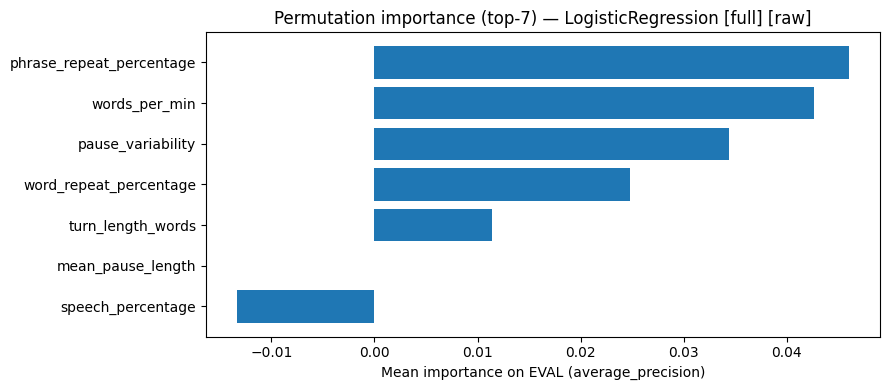


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['turn_length_words', 'phrase_repeat_percentage', 'words_per_min', 'pause_variability', 'word_repeat_percentage']
Train+Dev CV PR AUC: 0.4067433643165724 +/- 0.11503559514741786

Classification report:
               precision    recall  f1-score   support

           0      0.806     0.641     0.714        39
           1      0.440     0.647     0.524        17

    accuracy                          0.643        56
   macro avg      0.623     0.644     0.619        56
weighted avg      0.695     0.643     0.656        56

Confusion matrix:
 [[25 14]
 [ 6 11]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.052417        0.058039
           words_per_min         0.044756 

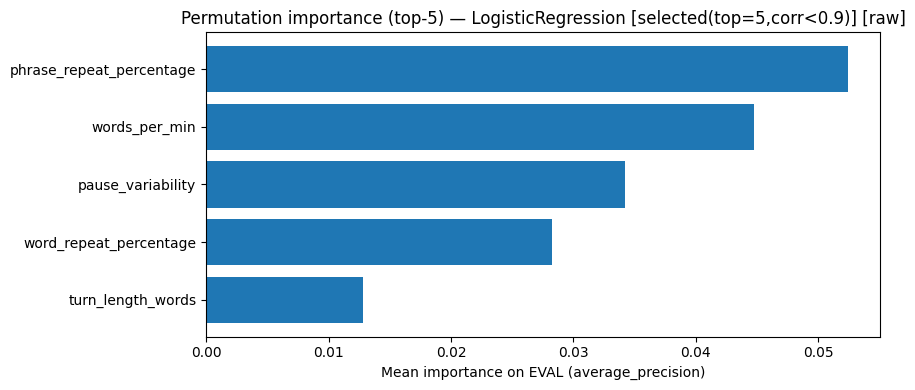


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Best CV score: 0.4024 Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.4024182026968834 +/- 0.10996620982910343

Classification report:
               precision    recall  f1-score   support

           0      0.786     0.564     0.657        39
           1      0.393     0.647     0.489        17

    accuracy                          0.589        56
   macro avg      0.589     0.606     0.573        56
weighted avg      0.666     0.589     0.606        56

Confusion matrix:
 [[22 17]
 [ 6 11]]

[SVM [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           words_per_min         0.049645        0.046633
  word_repeat_percentage         0.035347        0.040113
phrase_repeat_percentage         0.031632        0.065322
       turn_le

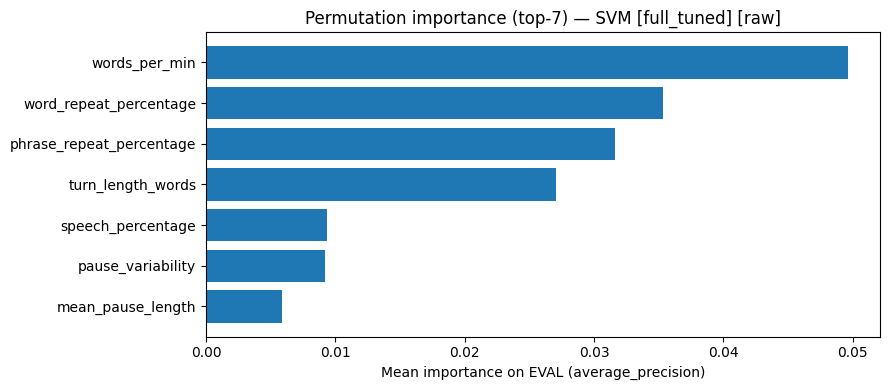


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['word_repeat_percentage', 'phrase_repeat_percentage', 'turn_length_words', 'pause_variability']
Best CV score: 0.4198 Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.41984792787345776 +/- 0.11884402480122366

Classification report:
               precision    recall  f1-score   support

           0      0.793     0.590     0.676        39
           1      0.407     0.647     0.500        17

    accuracy                          0.607        56
   macro avg      0.600     0.618     0.588        56
weighted avg      0.676     0.607     0.623        56

Confusion matrix:
 [[23 16]
 [ 6 11]]

[SVM [selected_tuned]] Top-4 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.069524        0.049832
       pau

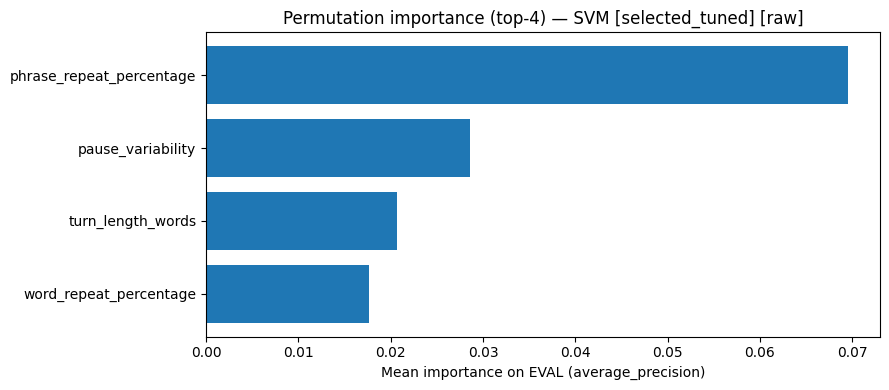


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Train+Dev CV PR AUC: 0.3309774234757965 +/- 0.12571404276473908

Classification report:
               precision    recall  f1-score   support

           0      0.697     0.590     0.639        39
           1      0.304     0.412     0.350        17

    accuracy                          0.536        56
   macro avg      0.501     0.501     0.494        56
weighted avg      0.578     0.536     0.551        56

Confusion matrix:
 [[23 16]
 [10  7]]

[SGDClassifier(log_loss) [full]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           words_per_min         0.019881        0.031825
       turn_length_words         0.007976        0.042551
       pause_variability        -0.000054        0.000161
       mean_pause_length        -0.024100        0.020139
  word_repeat_percentage   

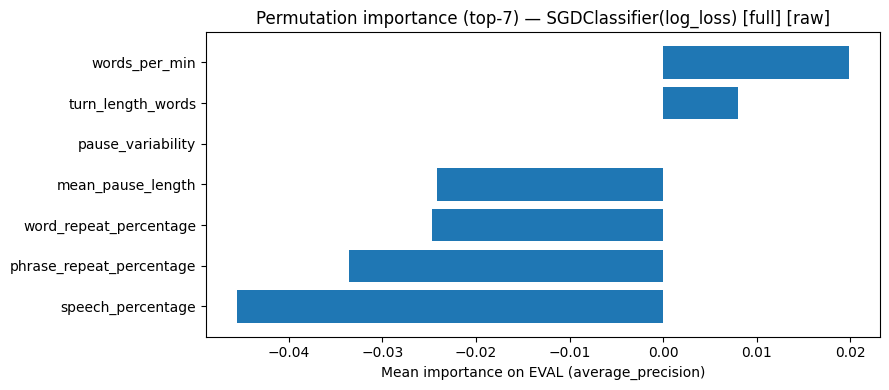


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['words_per_min', 'pause_variability', 'turn_length_words', 'speech_percentage']
Train+Dev CV PR AUC: 0.3390895023632911 +/- 0.07448767011547433

Classification report:
               precision    recall  f1-score   support

           0      0.826     0.487     0.613        39
           1      0.394     0.765     0.520        17

    accuracy                          0.571        56
   macro avg      0.610     0.626     0.566        56
weighted avg      0.695     0.571     0.585        56

Confusion matrix:
 [[19 20]
 [ 4 13]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
          feature  importance_mean  importance_std
    words_per_min         0.201063        0.057336
speech_percentage         0.028038        0.029236
pause_variability         0.

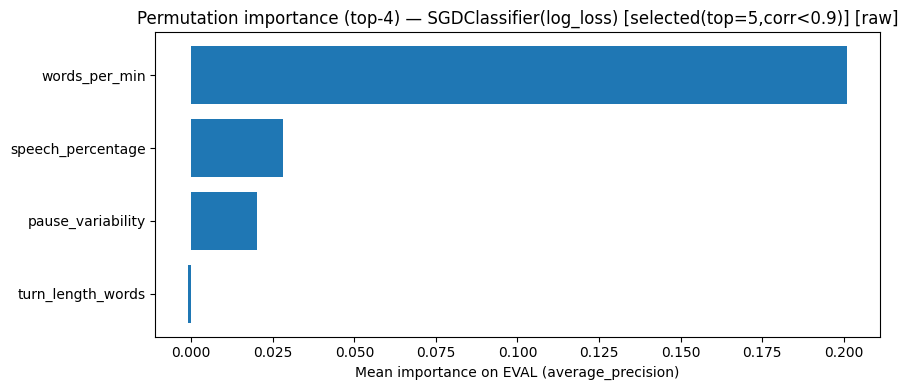


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Best CV score: 0.2825 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.28251850669289763 +/- 0.018948698064668954

Classification report:
               precision    recall  f1-score   support

           0      0.682     0.385     0.492        39
           1      0.294     0.588     0.392        17

    accuracy                          0.446        56
   macro avg      0.488     0.486     0.442        56
weighted avg      0.564     0.446     0.462        56

Confusion matrix:
 [[15 24]
 [ 7 10]]

[DecisionTree [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           words_per_min         0.044581        0.028023
       mean_pause_length         0.018012        0.035883
       turn_length_words         0.00

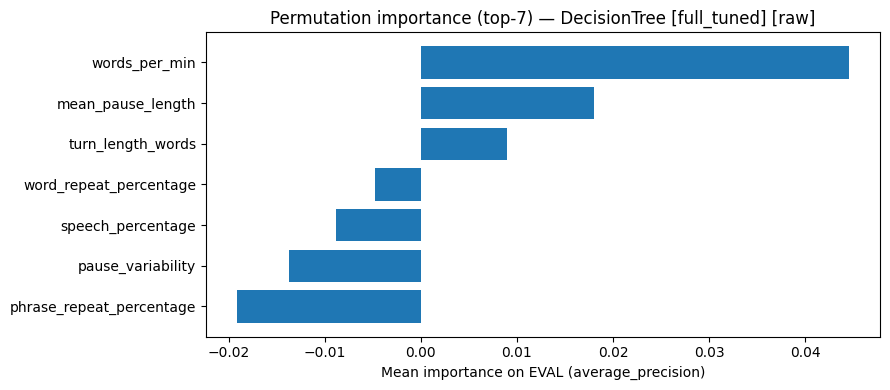

[WARN] DecisionTree[selected]: very few unique predicted probabilities (5).

=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['speech_percentage', 'words_per_min', 'turn_length_words', 'phrase_repeat_percentage', 'pause_variability']
Best CV score: 0.3309 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.33089777834816203 +/- 0.06296200170434732

Classification report:
               precision    recall  f1-score   support

           0      0.737     0.359     0.483        39
           1      0.324     0.706     0.444        17

    accuracy                          0.464        56
   macro avg      0.531     0.532     0.464        56
weighted avg      0.612     0.464     0.471        56

Confusion matrix:
 [[14 25]
 [ 5 12]]

[DecisionTree [selected_tuned]] Top-5 permutation importances (average_precision, raw):
    

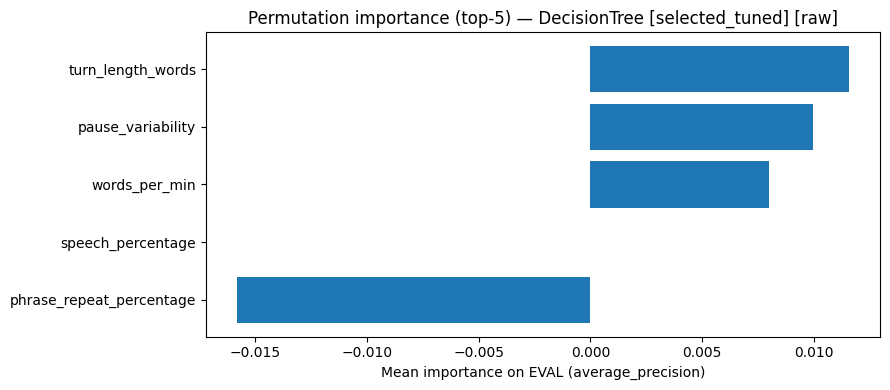


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Best CV score: 0.3894 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.38936608366981285 +/- 0.13283973859090686

Classification report:
               precision    recall  f1-score   support

           0      0.714     0.769     0.741        39
           1      0.357     0.294     0.323        17

    accuracy                          0.625        56
   macro avg      0.536     0.532     0.532        56
weighted avg      0.606     0.625     0.614        56

Confusion matrix:
 [[30  9]
 [12  5]]

[RandomForest [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
  word_repeat_percentage        -0.000370        0.043196
           words_

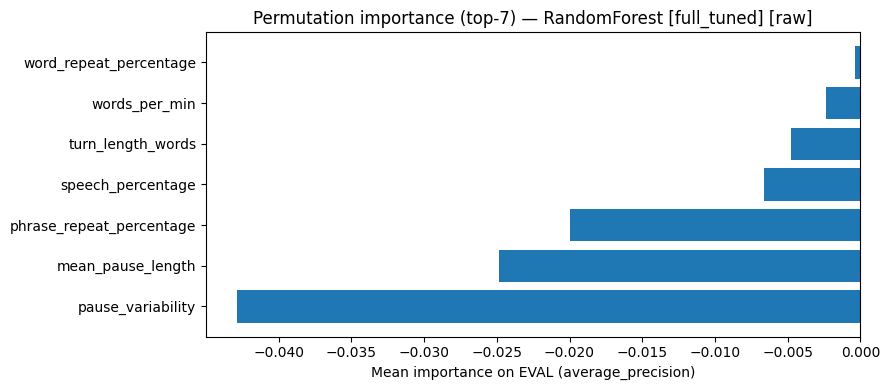


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['turn_length_words', 'pause_variability', 'word_repeat_percentage', 'phrase_repeat_percentage', 'words_per_min']
Best CV score: 0.3794 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.37938093303789505 +/- 0.11257753515572133

Classification report:
               precision    recall  f1-score   support

           0      0.683     0.718     0.700        39
           1      0.267     0.235     0.250        17

    accuracy                          0.571        56
   macro avg      0.475     0.477     0.475        56
weighted avg      0.557     0.571     0.563        56

Confusion matrix:
 [[28 11]
 [13  4]]

[RandomForest [selected_tuned]] Top-5 permutation importances (average_precision, ra

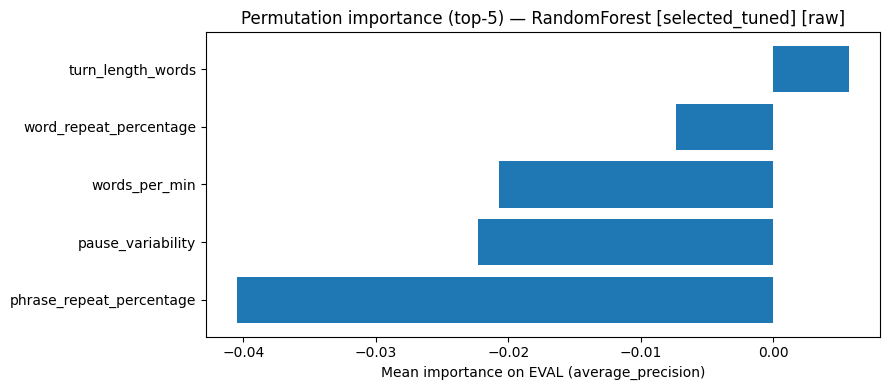


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Best CV score: 0.3719 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.3718879343116127 +/- 0.09017281470347831

Classification report:
               precision    recall  f1-score   support

           0      0.679     0.487     0.567        39
           1      0.286     0.471     0.356        17

    accuracy                          0.482        56
   macro avg      0.482     0.479     0.461        56
weighted avg      0.559     0.482     0.503        56

Confusion matrix:
 [[19 20]
 [ 9  8]]

[XGBoost [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.022803        0.025215
     

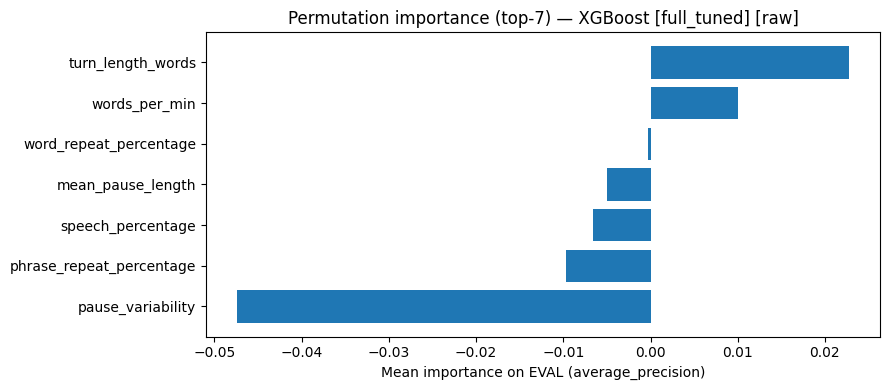


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_small_test3.csv) ===
Selected cols: ['turn_length_words', 'word_repeat_percentage', 'speech_percentage', 'pause_variability', 'phrase_repeat_percentage']
Best CV score: 0.3959 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 10, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.395872903347652 +/- 0.0941719695684219

Classification report:
               precision    recall  f1-score   support

           0      0.732     0.769     0.750        39
           1      0.400     0.353     0.375        17

    accuracy                          0.643        56
   macro avg      0.566     0.561     0.562        56
weighted avg      0.631     0.643     0.636        56

Confusion matrix:
 [[30  9]
 [11  6]]

[XGBoost [selected_tuned]] Top-5 permutation importances (averag

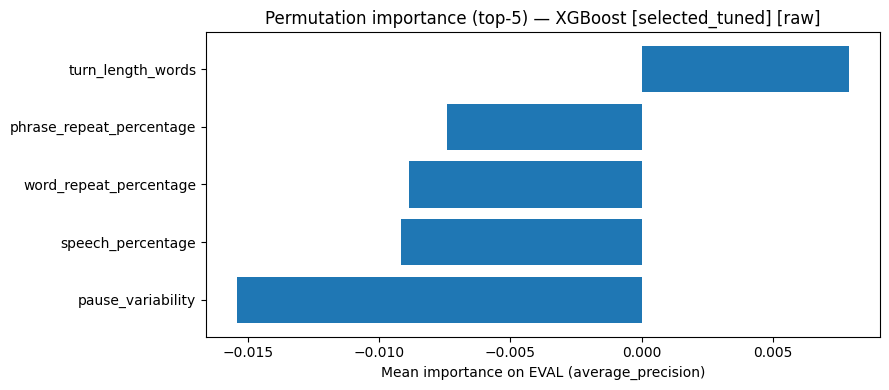


=== Summary metrics on TEST (tuned by PR AUC) ===
          target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                           best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  pr_auc_lo  pr_auc_hi  brier                                                                                         selected_cols
Depression_label      LogisticRegression                     full  False            NaN          0.4004         0.1160                                                                                                                                                                                            219      56               7                  NaN    0.6607    0.6345 0.5083 

In [3]:
res_b0_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    target_col="Depression_label",
    importance_top_k=5,
)


In [4]:
res_b0_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,pr_auc_lo,pr_auc_hi,brier,selected_cols
0,Depression_label,LogisticRegression,full,False,NaN,0.400439,0.116013,,219,56,...,0.761024,0.656863,0.601810,0.419268,0.770814,0.437071,0.314877,0.671812,0.249804,
1,Depression_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.406743,0.115036,,219,56,...,0.744292,0.644042,0.604827,0.420777,0.773756,0.440591,0.317364,0.673211,0.249930,"turn_length_words,phrase_repeat_percentage,wor..."
2,Depression_label,SVM,full_tuned,True,0.402418,0.402418,0.109966,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k...",219,56,...,0.695238,0.605581,0.622926,0.440422,0.793363,0.452611,0.328202,0.694661,0.211701,
3,Depression_label,SVM,selected_tuned,True,0.419848,0.419848,0.118844,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke...",219,56,...,0.711439,0.618401,0.576169,0.399661,0.746606,0.393465,0.293692,0.625682,0.219208,"word_repeat_percentage,phrase_repeat_percentag..."
4,Depression_label,SGDClassifier(log_loss),full,False,NaN,0.330977,0.125714,,219,56,...,0.626273,0.500754,0.538462,0.380090,0.692308,0.357454,0.271959,0.558244,0.444342,
5,Depression_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.339090,0.074488,,219,56,...,0.688380,0.625943,0.683258,0.512821,0.834087,0.570423,0.400587,0.766580,0.390712,"words_per_min,pause_variability,turn_length_wo..."
6,Depression_label,DecisionTree,full_tuned,True,0.282519,0.282519,0.018949,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.565891,0.486425,0.552036,0.384597,0.708899,0.347534,0.268864,0.527645,0.347872,
7,Depression_label,DecisionTree,selected_tuned,True,0.330898,0.330898,0.062962,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.585985,0.532428,0.556561,0.394419,0.703639,0.343774,0.272559,0.503190,0.295177,"speech_percentage,words_per_min,turn_length_wo..."
8,Depression_label,RandomForest,full_tuned,True,0.389366,0.389366,0.132840,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.666667,0.531674,0.511312,0.328808,0.690799,0.346266,0.264143,0.556169,0.251579,
9,Depression_label,RandomForest,selected_tuned,True,0.379381,0.379381,0.112578,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.606250,0.476621,0.511312,0.342345,0.681750,0.348080,0.262040,0.564309,0.252581,"turn_length_words,pause_variability,word_repea..."



[INFO] target_col = Depression_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 13) | X_test shape: (56, 13)
[INFO] class counts train: [170  49] | test: [39 17]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Train+Dev CV PR AUC: 0.3416354620375655 +/- 0.13276366537564513

Classification report:
               precision    recall  f1-score   support

           0      0.812     0.667     0.732        39
           1      0.458     0.647     0.537        17

    accuracy                          0.661        56
   macro avg      0.635     0.657     0.634        56
weighted avg      0.705     0.661     0.673        56

Confusion matrix:
 [[26 13]
 [ 6 11]]

[LogisticRegression [full]] Top-10 permutation importances (average_precision, raw):
                            

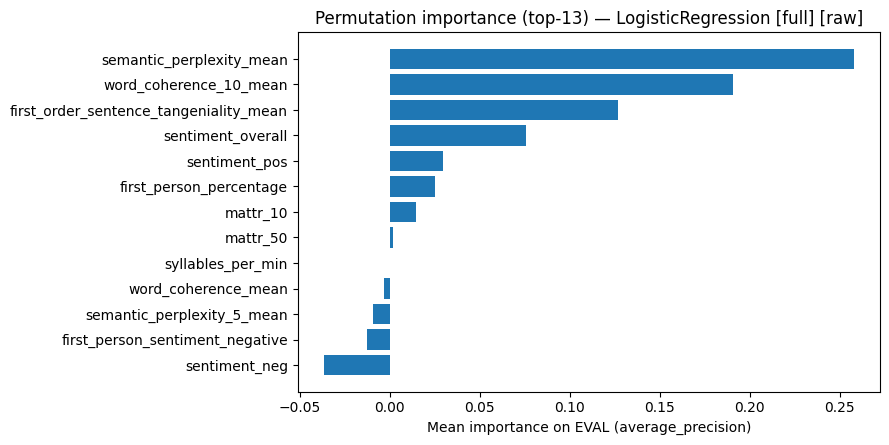


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['word_coherence_10_mean', 'mattr_50', 'sentiment_overall', 'semantic_perplexity_mean', 'sentiment_neg']
Train+Dev CV PR AUC: 0.39476645145320644 +/- 0.16654766106569147

Classification report:
               precision    recall  f1-score   support

           0      0.800     0.615     0.696        39
           1      0.423     0.647     0.512        17

    accuracy                          0.625        56
   macro avg      0.612     0.631     0.604        56
weighted avg      0.686     0.625     0.640        56

Confusion matrix:
 [[24 15]
 [ 6 11]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
semantic_perplexity_mean         0.236213        0.041204
  word_coherence_10_mean         0.157845        0.

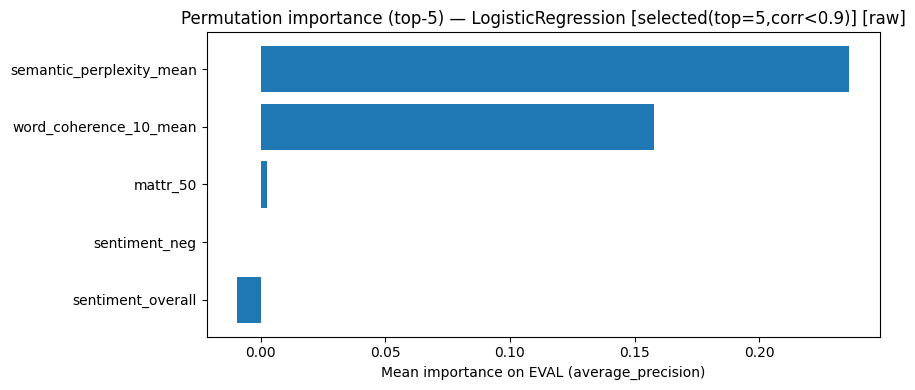


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Best CV score: 0.3569 Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.3568510530209685 +/- 0.14952827394613505

Classification report:
               precision    recall  f1-score   support

           0      0.839     0.667     0.743        39
           1      0.480     0.706     0.571        17

    accuracy                          0.679        56
   macro avg      0.659     0.686     0.657        56
weighted avg      0.730     0.679     0.691        56

Confusion matrix:
 [[26 13]
 [ 5 12]]

[SVM [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              semantic_perplexity_mean         0.237216        0.041268
                word_coherence_10_mean         0.168821        0.070619
first_order_sentence_tangenialit

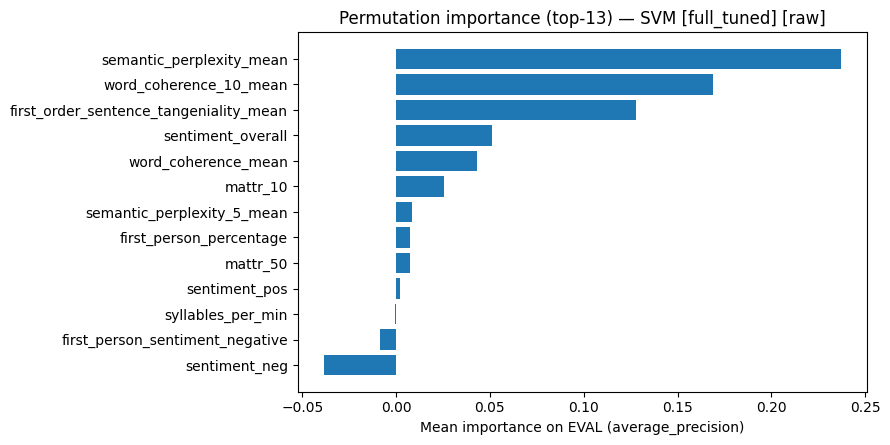


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['first_person_percentage', 'sentiment_pos', 'word_coherence_10_mean', 'syllables_per_min']
Best CV score: 0.3374 Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.3373723385006641 +/- 0.064951781480679

Classification report:
               precision    recall  f1-score   support

           0      0.792     0.487     0.603        39
           1      0.375     0.706     0.490        17

    accuracy                          0.554        56
   macro avg      0.583     0.597     0.546        56
weighted avg      0.665     0.554     0.569        56

Confusion matrix:
 [[19 20]
 [ 5 12]]

[SVM [selected_tuned]] Top-4 permutation importances (average_precision, raw):
                feature  importance_mean  importance_std
      syllables_per_min         0.014238        0.008042
first_person_percent

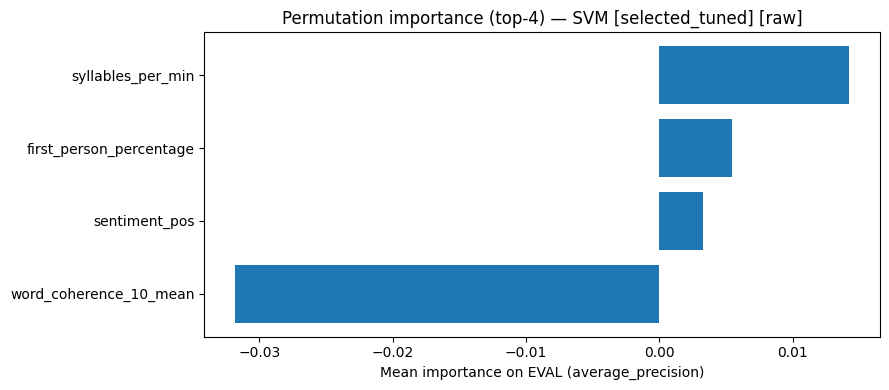


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Train+Dev CV PR AUC: 0.40273162113289585 +/- 0.13658660067186967

Classification report:
               precision    recall  f1-score   support

           0      0.760     0.487     0.594        39
           1      0.355     0.647     0.458        17

    accuracy                          0.536        56
   macro avg      0.557     0.567     0.526        56
weighted avg      0.637     0.536     0.553        56

Confusion matrix:
 [[19 20]
 [ 6 11]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              semantic_perplexity_mean         0.095371        0.031896
                word_coherence_10_mean         0.037587        0.060356
                     sentiment_overall         0.036735        0.020479
first_order_sentence_tangeni

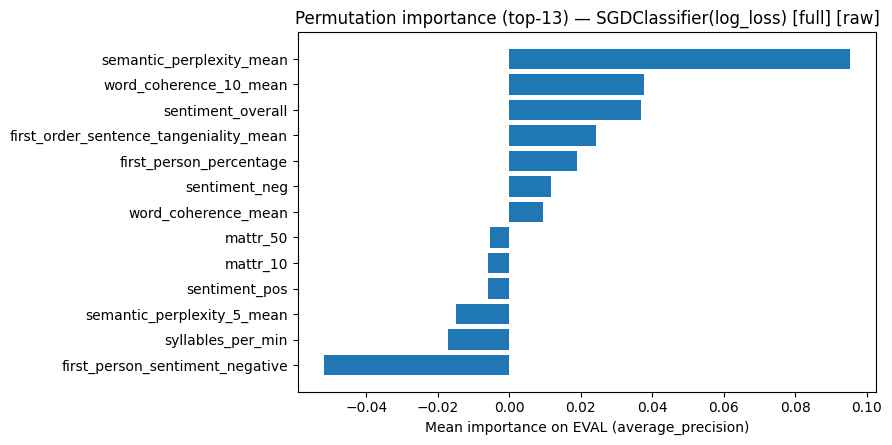


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['word_coherence_10_mean', 'semantic_perplexity_mean', 'first_person_percentage', 'first_person_sentiment_negative']
Train+Dev CV PR AUC: 0.3946712850638706 +/- 0.13722699363647595

Classification report:
               precision    recall  f1-score   support

           0      0.739     0.436     0.548        39
           1      0.333     0.647     0.440        17

    accuracy                          0.500        56
   macro avg      0.536     0.541     0.494        56
weighted avg      0.616     0.500     0.515        56

Confusion matrix:
 [[17 22]
 [ 6 11]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-4 permutation importances (average_precision, raw):
                        feature  importance_mean  importance_std
       semantic_perplexity_mean         0.058850        0.017328
         word_co

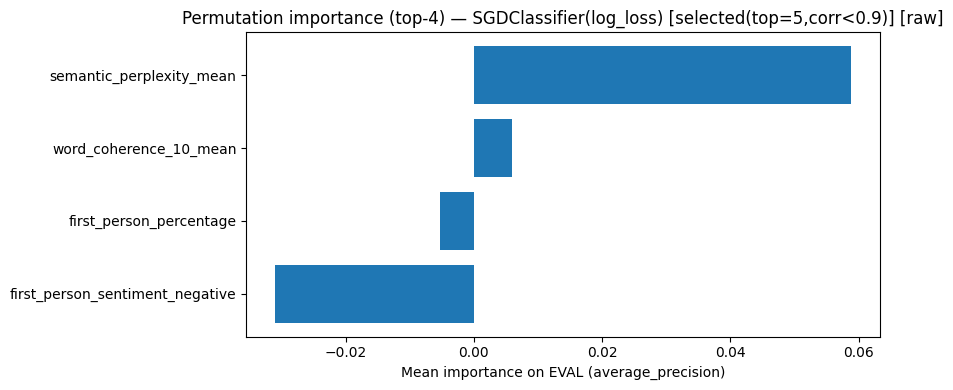


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Best CV score: 0.2776 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.2776411915195821 +/- 0.03220004760896076

Classification report:
               precision    recall  f1-score   support

           0      0.742     0.590     0.657        39
           1      0.360     0.529     0.429        17

    accuracy                          0.571        56
   macro avg      0.551     0.560     0.543        56
weighted avg      0.626     0.571     0.588        56

Confusion matrix:
 [[23 16]
 [ 8  9]]

[DecisionTree [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                word_coherence_10_mean         0.034233        0.025766
               first_person_percentage         0.027916        0.0162

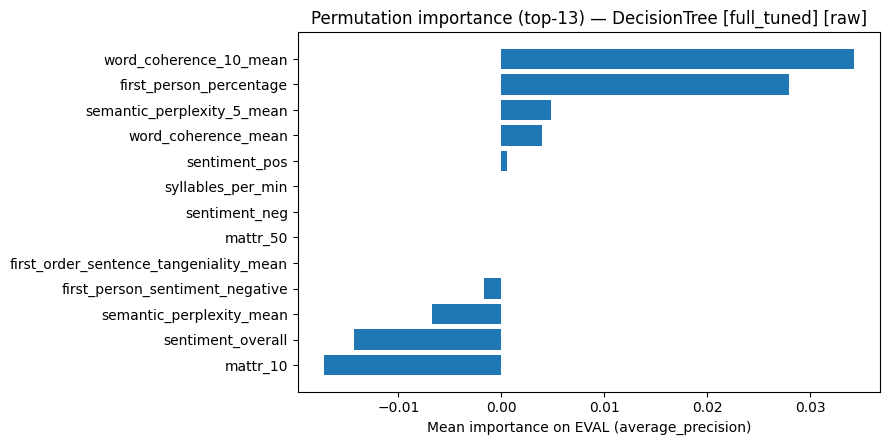

[WARN] DecisionTree[selected]: very few unique predicted probabilities (5).

=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['word_coherence_10_mean', 'sentiment_overall', 'mattr_10', 'sentiment_pos']
Best CV score: 0.3261 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10}
Train+Dev CV PR AUC: 0.32605647081813605 +/- 0.10900823449028042

Classification report:
               precision    recall  f1-score   support

           0      0.708     0.436     0.540        39
           1      0.312     0.588     0.408        17

    accuracy                          0.482        56
   macro avg      0.510     0.512     0.474        56
weighted avg      0.588     0.482     0.500        56

Confusion matrix:
 [[17 22]
 [ 7 10]]

[DecisionTree [selected_tuned]] Top-4 permutation importances (average_precision, raw):
               feature  importance_m

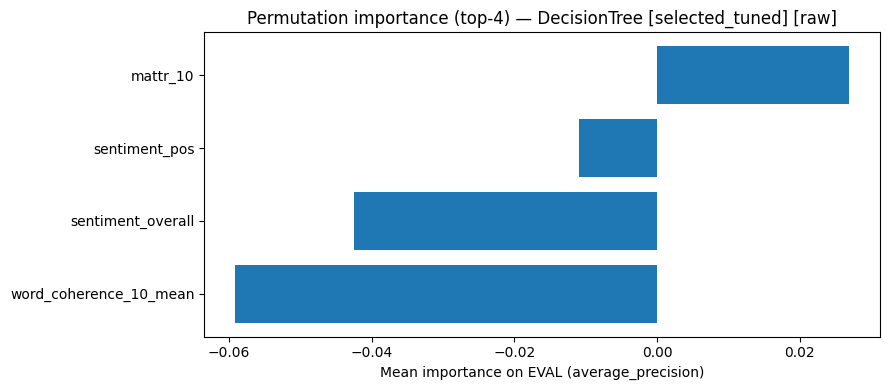


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Best CV score: 0.2634 Best params: {'clf__bootstrap': True, 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.26344838125295345 +/- 0.05144878188540103

Classification report:
               precision    recall  f1-score   support

           0      0.702     0.846     0.767        39
           1      0.333     0.176     0.231        17

    accuracy                          0.643        56
   macro avg      0.518     0.511     0.499        56
weighted avg      0.590     0.643     0.605        56

Confusion matrix:
 [[33  6]
 [14  3]]

[RandomForest [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              semantic_perplexity_mean         0.032946     

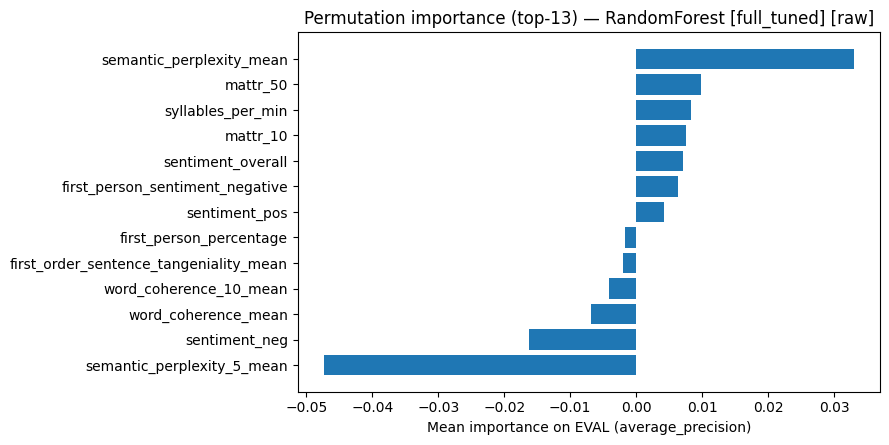


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['word_coherence_10_mean', 'semantic_perplexity_mean', 'syllables_per_min', 'sentiment_overall']
Best CV score: 0.3374 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 500}
Train+Dev CV PR AUC: 0.33742149252072207 +/- 0.09634423967579868

Classification report:
               precision    recall  f1-score   support

           0      0.773     0.872     0.819        39
           1      0.583     0.412     0.483        17

    accuracy                          0.732        56
   macro avg      0.678     0.642     0.651        56
weighted avg      0.715     0.732     0.717        56

Confusion matrix:
 [[34  5]
 [10  7]]

[RandomForest [selected_tuned]] Top-4 permutation importances (average_precision, raw):
              

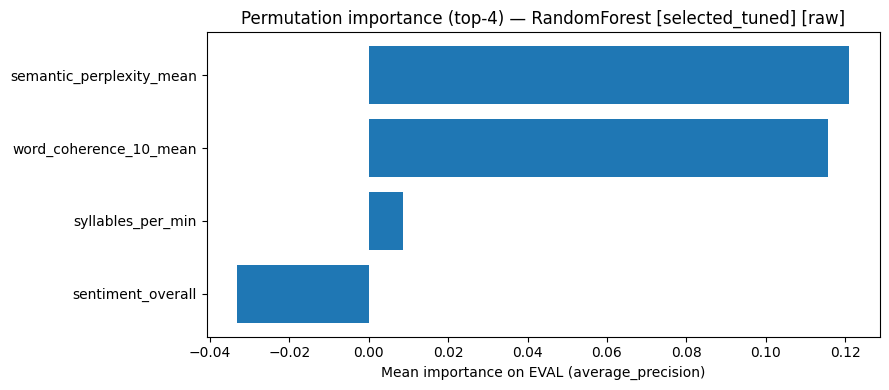


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Best CV score: 0.2735 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__min_child_weight': 5, 'clf__n_estimators': 500, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.2734592026002425 +/- 0.08751724508199779

Classification report:
               precision    recall  f1-score   support

           0      0.703     0.667     0.684        39
           1      0.316     0.353     0.333        17

    accuracy                          0.571        56
   macro avg      0.509     0.510     0.509        56
weighted avg      0.585     0.571     0.578        56

Confusion matrix:
 [[26 13]
 [11  6]]

[XGBoost [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              semantic_perplexity_mean         0.

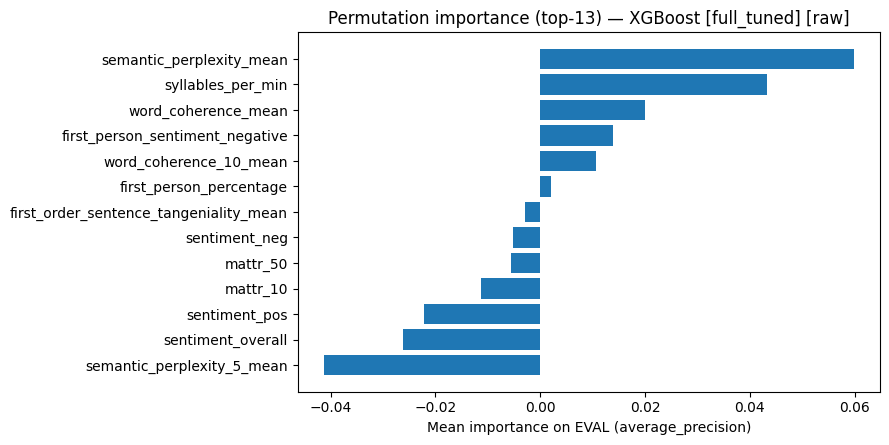


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_small_test3.csv) ===
Selected cols: ['word_coherence_10_mean', 'mattr_50', 'mattr_10']
Best CV score: 0.3516 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__min_child_weight': 5, 'clf__n_estimators': 500, 'clf__reg_lambda': 1.0, 'clf__subsample': 1.0}
Train+Dev CV PR AUC: 0.35159489660976456 +/- 0.05212176516555493

Classification report:
               precision    recall  f1-score   support

           0      0.750     0.769     0.759        39
           1      0.438     0.412     0.424        17

    accuracy                          0.661        56
   macro avg      0.594     0.590     0.592        56
weighted avg      0.655     0.661     0.658        56

Confusion matrix:
 [[30  9]
 [10  7]]

[XGBoost [selected_tuned]] Top-3 permutation importances (average_precision, raw):
               feature  importance_mean  import

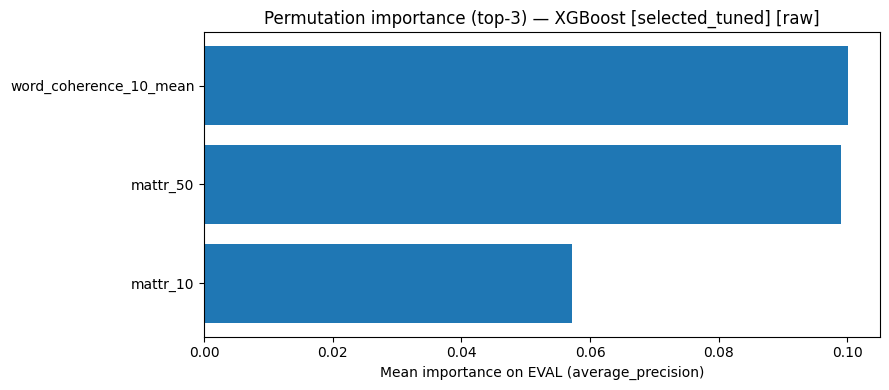


=== Summary metrics on TEST (tuned by PR AUC) ===
          target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  pr_auc_lo  pr_auc_hi  brier                                                                                           selected_cols
Depression_label      LogisticRegression                     full  False            NaN          0.3416         0.1328                                                                                                                                                                                           219      56              13                  NaN    0.6607    0.6345 0.5048 

In [5]:
res_l_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    target_col="Depression_label",
    importance_top_k=5,
)

In [6]:
res_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,pr_auc_lo,pr_auc_hi,brier,selected_cols
0,Depression_label,LogisticRegression,full,False,NaN,0.341635,0.132764,,219,56,...,0.749914,0.656863,0.687783,0.520362,0.835633,0.565066,0.401735,0.767479,0.216944,
1,Depression_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.394766,0.166548,,219,56,...,0.721393,0.631222,0.693816,0.526357,0.837142,0.546407,0.383826,0.751467,0.227947,"word_coherence_10_mean,mattr_50,sentiment_over..."
2,Depression_label,SVM,full_tuned,True,0.356851,0.356851,0.149528,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",219,56,...,0.771429,0.686275,0.690799,0.520362,0.838650,0.545833,0.385419,0.751307,0.213567,
3,Depression_label,SVM,selected_tuned,True,0.337372,0.337372,0.064952,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k...",219,56,...,0.671875,0.596531,0.432881,0.268477,0.595777,0.315463,0.238743,0.520632,0.225358,"first_person_percentage,sentiment_pos,word_coh..."
4,Depression_label,SGDClassifier(log_loss),full,False,NaN,0.402732,0.136587,,219,56,...,0.651718,0.567119,0.558069,0.386124,0.720965,0.374661,0.285480,0.597499,0.432419,
5,Depression_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.394671,0.137227,,219,56,...,0.619048,0.541478,0.570136,0.399698,0.731561,0.383588,0.289337,0.603695,0.457710,"word_coherence_10_mean,semantic_perplexity_mea..."
6,Depression_label,DecisionTree,full_tuned,True,0.277641,0.277641,0.032200,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.672515,0.559578,0.618401,0.453978,0.766214,0.399660,0.292483,0.602966,0.312687,
7,Depression_label,DecisionTree,selected_tuned,True,0.326056,0.326056,0.109008,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.596015,0.512066,0.492459,0.327300,0.642534,0.347189,0.261605,0.460560,0.318839,"word_coherence_10_mean,sentiment_overall,mattr..."
8,Depression_label,RandomForest,full_tuned,True,0.263448,0.263448,0.051449,"{'clf__bootstrap': True, 'clf__max_depth': 10,...",219,56,...,0.633987,0.511312,0.588235,0.420814,0.752640,0.448830,0.306852,0.634073,0.213591,
9,Depression_label,RandomForest,selected_tuned,True,0.337421,0.337421,0.096344,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.781250,0.641780,0.663650,0.497700,0.814480,0.487394,0.357084,0.702784,0.204754,"word_coherence_10_mean,semantic_perplexity_mea..."



[INFO] target_col = Depression_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 20) | X_test shape: (56, 20)
[INFO] class counts train: [170  49] | test: [39 17]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Train+Dev CV PR AUC: 0.40477981437571336 +/- 0.13502360434160504

Classification report:
               precision    recall  f1-score   support

           0      0.744     0.744     0.744        39
           1      0.412     0.412     0.412        17

    accuracy                          0.643        56
   macro avg      0.578     0.578     0.578        56
weighted avg      0.643     0.643     0.643        56

Confusion matrix:
 [[29 10]
 [10  7]]

[LogisticRegression [full]] Top-10 permutation importances (average_precision, raw):
                         

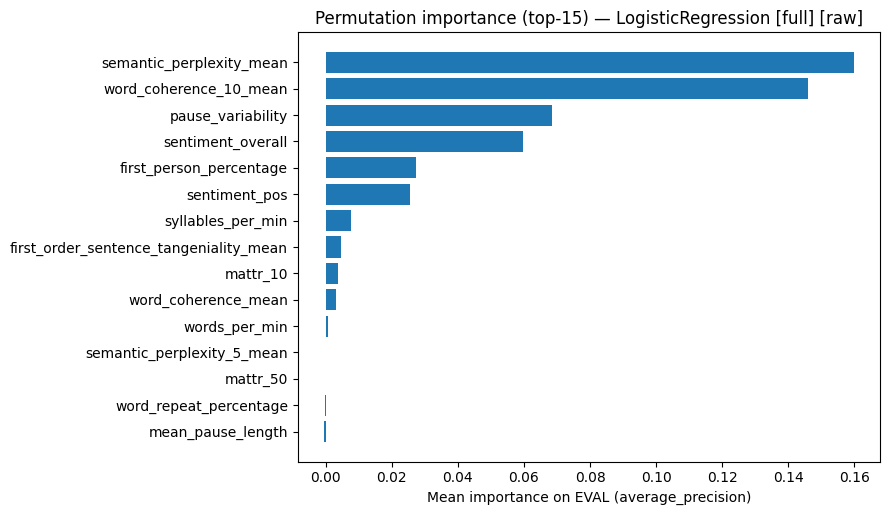


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['word_coherence_10_mean', 'pause_variability', 'sentiment_overall', 'turn_length_words', 'semantic_perplexity_mean']
Train+Dev CV PR AUC: 0.4399258503806528 +/- 0.133432550732599

Classification report:
               precision    recall  f1-score   support

           0      0.839     0.667     0.743        39
           1      0.480     0.706     0.571        17

    accuracy                          0.679        56
   macro avg      0.659     0.686     0.657        56
weighted avg      0.730     0.679     0.691        56

Confusion matrix:
 [[26 13]
 [ 5 12]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
semantic_perplexity_mean         0.239530        0.056032
  word_coherence_10_mean         0.1709

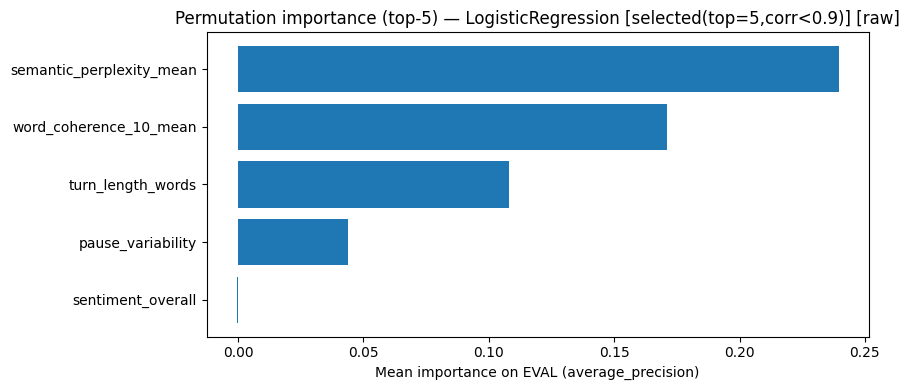


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Best CV score: 0.4223 Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.4222837118204038 +/- 0.14680647639668148

Classification report:
               precision    recall  f1-score   support

           0      0.750     0.615     0.676        39
           1      0.375     0.529     0.439        17

    accuracy                          0.589        56
   macro avg      0.562     0.572     0.558        56
weighted avg      0.636     0.589     0.604        56

Confusion matrix:
 [[24 15]
 [ 8  9]]

[SVM [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              semantic_perplexity_mean         0.161892        0.043459
                word_coherence_10_mean         0.117537        0.052283
                     pause_v

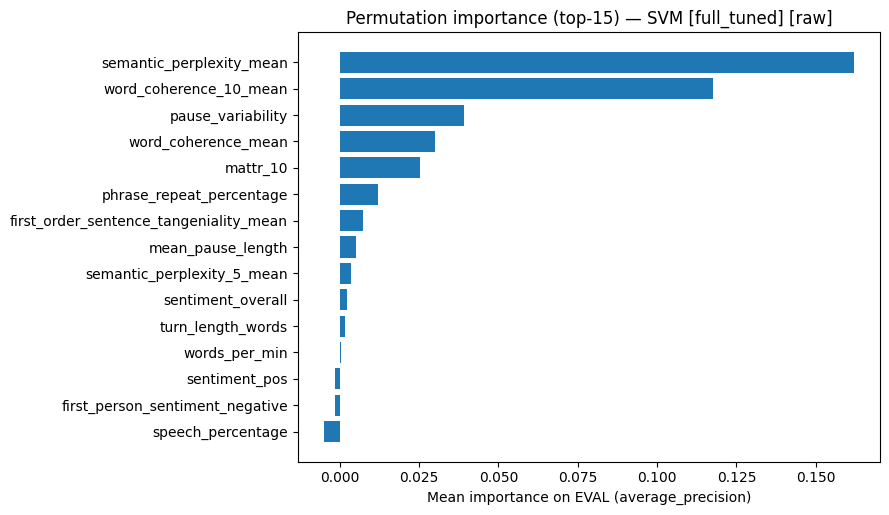


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['turn_length_words', 'phrase_repeat_percentage', 'first_person_percentage', 'word_coherence_10_mean', 'pause_variability']
Best CV score: 0.44 Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.4399853014567169 +/- 0.11364925502111564

Classification report:
               precision    recall  f1-score   support

           0      0.792     0.487     0.603        39
           1      0.375     0.706     0.490        17

    accuracy                          0.554        56
   macro avg      0.583     0.597     0.546        56
weighted avg      0.665     0.554     0.569        56

Confusion matrix:
 [[19 20]
 [ 5 12]]

[SVM [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
  word_coherence_10_mean         0.048852 

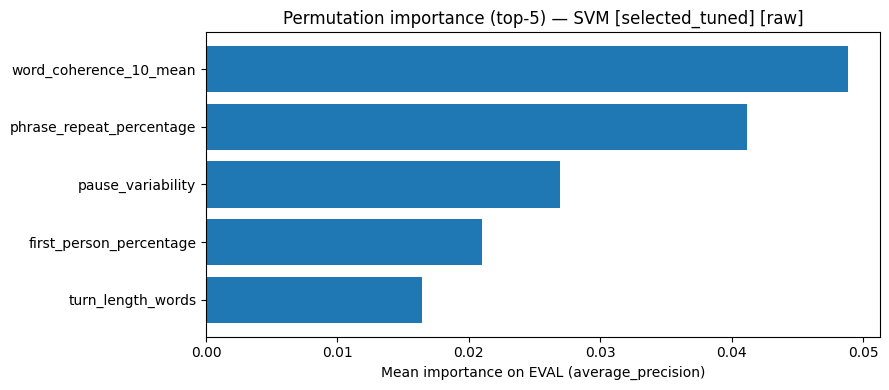


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Train+Dev CV PR AUC: 0.29727263828923584 +/- 0.09451922794283

Classification report:
               precision    recall  f1-score   support

           0      0.706     0.615     0.658        39
           1      0.318     0.412     0.359        17

    accuracy                          0.554        56
   macro avg      0.512     0.514     0.508        56
weighted avg      0.588     0.554     0.567        56

Confusion matrix:
 [[24 15]
 [10  7]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (average_precision, raw):
                   feature  importance_mean  importance_std
  semantic_perplexity_mean         0.069816        0.037307
         sentiment_overall         0.044133        0.014564
         pause_variability         0.043636        0.024159
    word_coherence_10_mean         0.042174        0.042753
   first_person_p

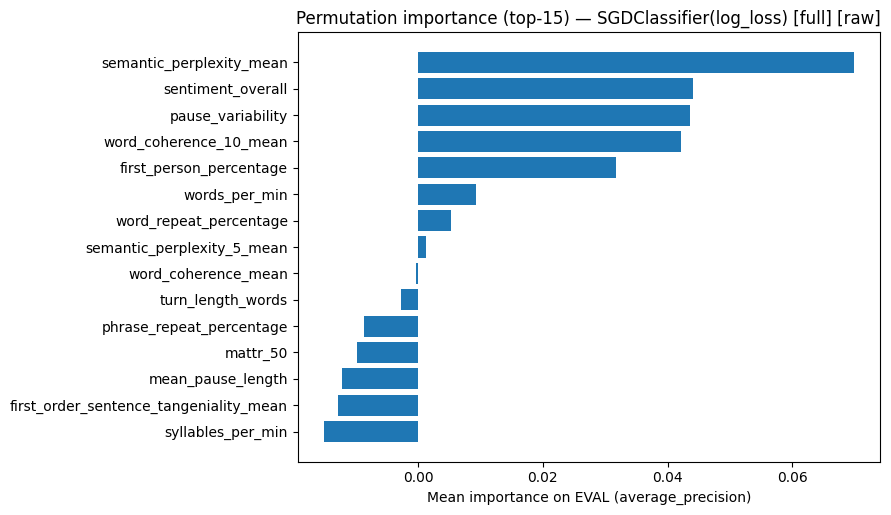


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['first_person_percentage', 'word_coherence_10_mean', 'pause_variability', 'phrase_repeat_percentage', 'turn_length_words']
Train+Dev CV PR AUC: 0.45000859583919545 +/- 0.024318401334114892

Classification report:
               precision    recall  f1-score   support

           0      0.762     0.821     0.790        39
           1      0.500     0.412     0.452        17

    accuracy                          0.696        56
   macro avg      0.631     0.616     0.621        56
weighted avg      0.682     0.696     0.687        56

Confusion matrix:
 [[32  7]
 [10  7]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
 first_person_percentage         0.031468        0.063845
       pause_variab

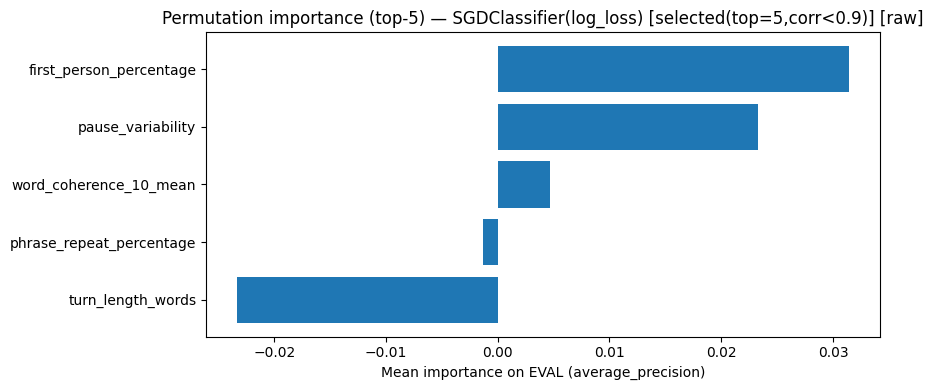


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Best CV score: 0.332 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.33202078244979105 +/- 0.056676081188568636

Classification report:
               precision    recall  f1-score   support

           0      0.771     0.692     0.730        39
           1      0.429     0.529     0.474        17

    accuracy                          0.643        56
   macro avg      0.600     0.611     0.602        56
weighted avg      0.667     0.643     0.652        56

Confusion matrix:
 [[27 12]
 [ 8  9]]

[DecisionTree [full_tuned]] Top-10 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
  word_coherence_10_mean         0.080565        0.023236
       speech_percentage         0.036005        0.025236
                mattr_10         0.0

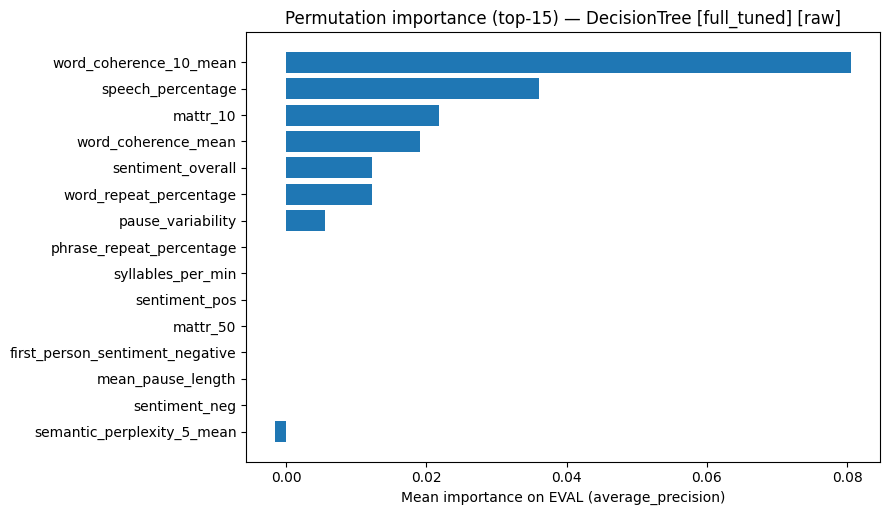


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['semantic_perplexity_mean', 'words_per_min', 'turn_length_words', 'word_repeat_percentage', 'word_coherence_10_mean']
Best CV score: 0.3603 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.3603327896205948 +/- 0.03113740198669057

Classification report:
               precision    recall  f1-score   support

           0      0.762     0.410     0.533        39
           1      0.343     0.706     0.462        17

    accuracy                          0.500        56
   macro avg      0.552     0.558     0.497        56
weighted avg      0.635     0.500     0.512        56

Confusion matrix:
 [[16 23]
 [ 5 12]]

[DecisionTree [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
  word_coher

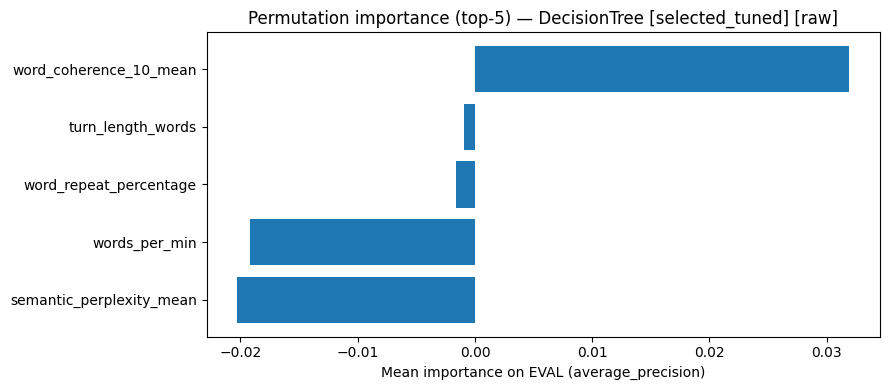


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Best CV score: 0.3509 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.3509107965206723 +/- 0.09167243271790405

Classification report:
               precision    recall  f1-score   support

           0      0.761     0.897     0.824        39
           1      0.600     0.353     0.444        17

    accuracy                          0.732        56
   macro avg      0.680     0.625     0.634        56
weighted avg      0.712     0.732     0.708        56

Confusion matrix:
 [[35  4]
 [11  6]]

[RandomForest [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              semantic_perplexity_mean         0.023941    

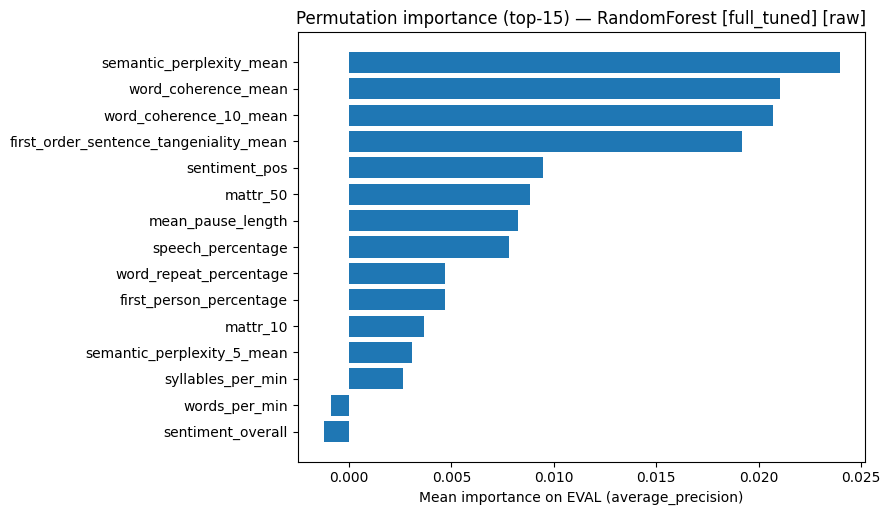


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['pause_variability', 'phrase_repeat_percentage', 'words_per_min', 'word_coherence_10_mean', 'syllables_per_min']
Best CV score: 0.3749 Best params: {'clf__bootstrap': True, 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.37492799597040916 +/- 0.10318624357869943

Classification report:
               precision    recall  f1-score   support

           0      0.756     0.795     0.775        39
           1      0.467     0.412     0.438        17

    accuracy                          0.679        56
   macro avg      0.611     0.603     0.606        56
weighted avg      0.668     0.679     0.673        56

Confusion matrix:
 [[31  8]
 [10  7]]

[RandomForest [selected_tuned]] Top-5 permutation importances (average_precision,

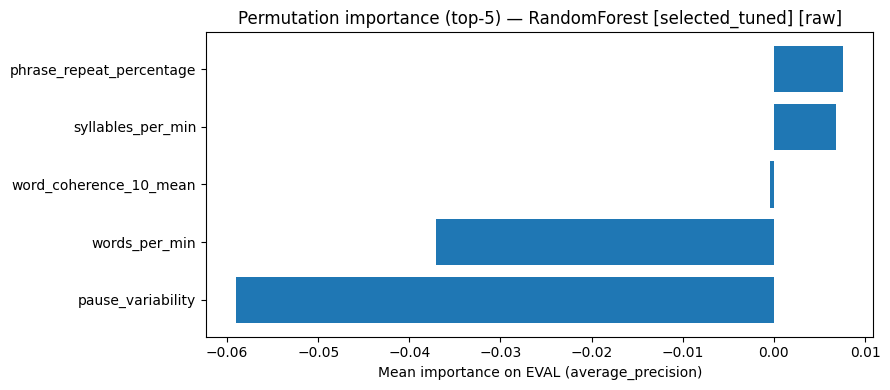


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Best CV score: 0.3579 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.3578822098565736 +/- 0.08228723985500028

Classification report:
               precision    recall  f1-score   support

           0      0.711     0.692     0.701        39
           1      0.333     0.353     0.343        17

    accuracy                          0.589        56
   macro avg      0.522     0.523     0.522        56
weighted avg      0.596     0.589     0.592        56

Confusion matrix:
 [[27 12]
 [11  6]]

[XGBoost [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              semantic_perplexity_mean         

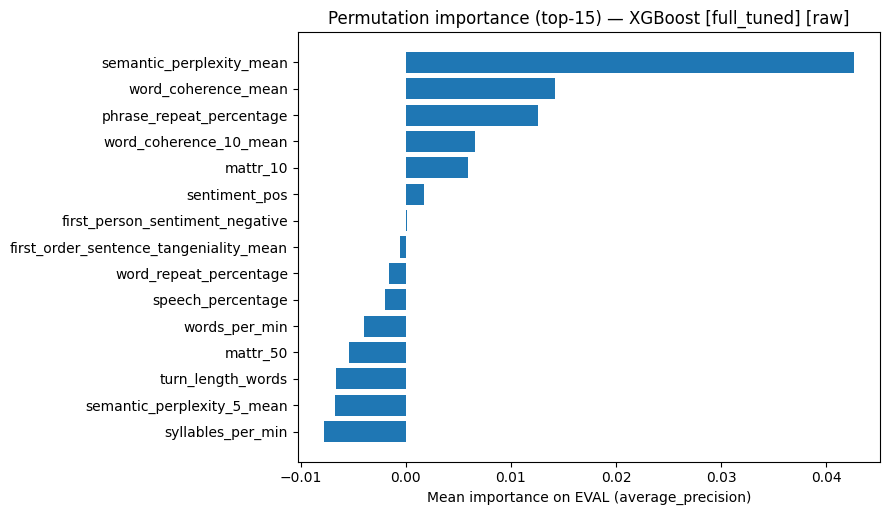


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_full3.csv) ===
Selected cols: ['phrase_repeat_percentage', 'pause_variability', 'word_coherence_mean', 'words_per_min']
Best CV score: 0.4354 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.4353839146507953 +/- 0.15556539867795022

Classification report:
               precision    recall  f1-score   support

           0      0.688     0.564     0.620        39
           1      0.292     0.412     0.341        17

    accuracy                          0.518        56
   macro avg      0.490     0.488     0.481        56
weighted avg      0.567     0.518     0.535        56

Confusion matrix:
 [[22 17]
 [10  7]]

[XGBoost [selected_tuned]] Top-4 permutation importances (average_precision, raw):
       

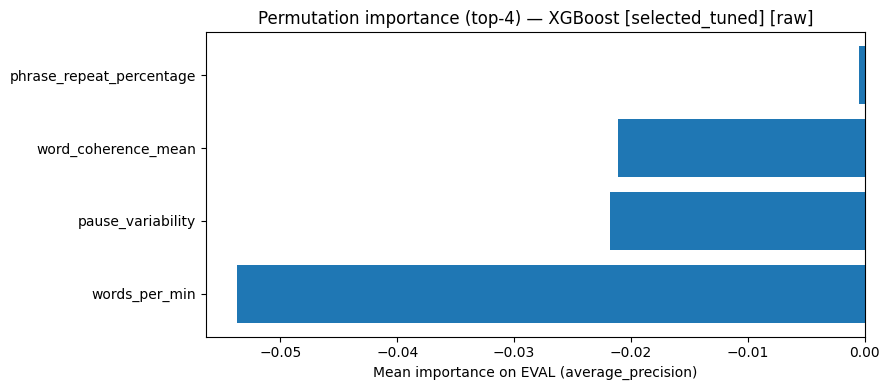


=== Summary metrics on TEST (tuned by PR AUC) ===
          target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  pr_auc_lo  pr_auc_hi  brier                                                                                               selected_cols
Depression_label      LogisticRegression                     full  False            NaN          0.4048         0.1350                                                                                                                                                                                           219      56              20                  NaN    0.6429    0.5777 0.4

In [7]:
res_b0_l_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_{LANGUAGE}_full{ITERATION}.csv",
    target_col="Depression_label",
    importance_top_k=5,
)

In [8]:
res_b0_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,pr_auc_lo,pr_auc_hi,brier,selected_cols
0,Depression_label,LogisticRegression,full,False,NaN,0.404780,0.135024,,219,56,...,0.710076,0.577677,0.606335,0.432881,0.772247,0.530708,0.368975,0.731493,0.223047,
1,Depression_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.439926,0.133433,,219,56,...,0.778018,0.686275,0.726998,0.568590,0.865762,0.592172,0.427969,0.796483,0.220172,"word_coherence_10_mean,pause_variability,senti..."
2,Depression_label,SVM,full_tuned,True,0.422284,0.422284,0.146806,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k...",219,56,...,0.681366,0.572398,0.628959,0.447964,0.799397,0.549113,0.381968,0.765622,0.208761,
3,Depression_label,SVM,selected_tuned,True,0.439985,0.439985,0.113649,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k...",219,56,...,0.667984,0.596531,0.618401,0.426848,0.788839,0.471026,0.332259,0.712073,0.210471,"turn_length_words,phrase_repeat_percentage,fir..."
4,Depression_label,SGDClassifier(log_loss),full,False,NaN,0.297273,0.094519,,219,56,...,0.641536,0.513575,0.544495,0.382334,0.705882,0.383763,0.280872,0.590548,0.424584,
5,Depression_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.450009,0.024318,,219,56,...,0.754679,0.616139,0.631976,0.453959,0.791855,0.457020,0.328256,0.689681,0.292004,"first_person_percentage,word_coherence_10_mean..."
6,Depression_label,DecisionTree,full_tuned,True,0.332021,0.332021,0.056676,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.729870,0.610860,0.586727,0.425339,0.734559,0.408098,0.304613,0.605186,0.306114,
7,Depression_label,DecisionTree,selected_tuned,True,0.360333,0.360333,0.031137,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.615057,0.558069,0.590498,0.431354,0.742836,0.368544,0.283207,0.517808,0.304896,"semantic_perplexity_mean,words_per_min,turn_le..."
8,Depression_label,RandomForest,full_tuned,True,0.350911,0.350911,0.091672,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.768276,0.625189,0.555053,0.366516,0.733032,0.416023,0.297333,0.655300,0.222767,
9,Depression_label,RandomForest,selected_tuned,True,0.374928,0.374928,0.103186,"{'clf__bootstrap': True, 'clf__max_depth': 10,...",219,56,...,0.737658,0.603318,0.517345,0.340837,0.687821,0.346613,0.269041,0.539234,0.240530,"pause_variability,phrase_repeat_percentage,wor..."


# fusing pipeline

In [9]:
import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Sequence, Dict, Any, List, Tuple
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False


# -------------------------
# Bootstrap CIs (extended to support PR AUC)
# -------------------------
def bootstrap_ci_binary(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    metric: str,
    n_boot: int = 2000,
    seed: int = 1706,
    stratified: bool = True,
) -> Tuple[float, float, float]:
    """
    Returns (boot_mean, lo_2.5, hi_97.5) for metric in {'f1_macro','auc','pr_auc'}.
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]
    if len(idx_pos) == 0 or len(idx_neg) == 0:
        return float("nan"), float("nan"), float("nan")

    scores: List[float] = []
    for _ in range(n_boot):
        if stratified:
            samp_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
            samp_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
            idx = np.concatenate([samp_pos, samp_neg])
        else:
            idx = rng.choice(len(y_true), size=len(y_true), replace=True)

        yt, yp, pr = y_true[idx], y_pred[idx], y_proba[idx]

        if metric == "f1_macro":
            s = f1_score(yt, yp, average="macro")
        elif metric == "auc":
            if len(np.unique(yt)) < 2:
                continue
            s = roc_auc_score(yt, pr)
        elif metric in ("pr_auc", "average_precision"):
            if len(np.unique(yt)) < 2:
                continue
            s = average_precision_score(yt, pr)
        else:
            raise ValueError("metric must be 'f1_macro', 'auc', or 'pr_auc'")

        scores.append(float(s))

    if not scores:
        return float("nan"), float("nan"), float("nan")

    lo, hi = np.percentile(scores, [2.5, 97.5])
    return float(np.mean(scores)), float(lo), float(hi)


# -------------------------
# Clean, leakage-safe late fusion / stacking
# -------------------------
def run_late_fusion_pipeline_clean(
    dataset_b0_path: str,
    dataset_l_path: str,
    *,
    id_col: str = "Participant",
    target_col: str = "PTSD_label",
    split_col: str = "split",
    train_values: Sequence[str] = ("train", "dev"),
    test_value: str = "test",

    # model choice
    base_model_b0: str = "LogisticRegression",
    base_model_l: Optional[str] = None,  # if None -> same as base_model_b0
    meta_C: float = 1.0,

    # leakage-safe drops policy
    drop_demographics: bool = True,          # drop age/gender/sex by default
    extra_drop_common: Optional[Sequence[str]] = None,
    extra_drop_b0: Optional[Sequence[str]] = None,
    extra_drop_l: Optional[Sequence[str]] = None,

    # CV / OOF
    n_splits: int = 5,
    random_state: int = 1706,

    # tuning (if enabled, it will be NESTED in OOF; correct, but slower)
    tune_tree_models: bool = False,
    grid_scoring: str = "average_precision",
    grid_n_jobs: int = 1,
    grid_verbose: int = 0,

    # importance
    compute_importance: bool = True,
    perm_scoring: str = "average_precision",
    perm_n_repeats: int = 10,
    plot_top_k: int = 15,

    # metrics / CIs
    n_boot: int = 2000,
) -> pd.DataFrame:
    """
    What is guaranteed:
      - strict alignment B0<->L by id_col
      - automatic leakage-safe drop based on target_col:
          drops: id_col, split_col, target_col,
                 ALL other *_label / *_severity columns,
                 + optionally demographics
      - base models trained on train+dev; test evaluated on test
      - stacking uses OOF probabilities on train+dev (no test leakage)
      - permutation importance computed on RAW columns (clean and readable)
    """

    if base_model_l is None:
        base_model_l = base_model_b0

    extra_drop_common = list(extra_drop_common or [])
    extra_drop_b0 = list(extra_drop_b0 or [])
    extra_drop_l = list(extra_drop_l or [])

    # ---------- helpers ----------
    def _build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        cat = [c for c in X.columns if X[c].dtype.name in ["object", "category", "bool"]]
        num = [c for c in X.columns if c not in cat]
        try:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

        return ColumnTransformer(
            transformers=[
                ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", ohe)]), cat),
                ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num),
            ],
            remainder="drop",
        )

    def _safe_n_splits(y: np.ndarray, desired: int) -> int:
        counts = Counter(y.tolist())
        min_class = min(counts.values()) if counts else 0
        return max(2, min(desired, min_class)) if min_class >= 2 else 0

    def _predict_proba(pipe: Pipeline, X: pd.DataFrame) -> np.ndarray:
        return pipe.predict_proba(X)[:, 1]

    def _best_threshold(y_true: np.ndarray, y_proba: np.ndarray, metric: str = "f1") -> float:
        thresholds = np.linspace(0.0, 1.0, 201)
        best_t = 0.5
        best_v = -np.inf
        for t in thresholds:
            y_hat = (y_proba >= t).astype(int)
            if metric == "balanced_acc":
                v = balanced_accuracy_score(y_true, y_hat)
            else:
                v = f1_score(y_true, y_hat, average="macro")
            if v > best_v:
                best_v = v
                best_t = t
        return float(best_t)

    # ---- UPDATED: add pr_auc_lo / pr_auc_hi ----
    def _metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> Dict[str, Any]:
        out = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
            "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
            "roc_auc": float(roc_auc_score(y_true, y_proba)) if len(np.unique(y_true)) == 2 else float("nan"),
            "pr_auc": float(average_precision_score(y_true, y_proba)) if len(np.unique(y_true)) == 2 else float("nan"),
            "brier": float(brier_score_loss(y_true, y_proba)),
            "f1_lo": float("nan"),
            "f1_hi": float("nan"),
            "auc_lo": float("nan"),
            "auc_hi": float("nan"),
            "pr_auc_lo": float("nan"),
            "pr_auc_hi": float("nan"),
        }

        if len(np.unique(y_true)) == 2:
            _, f1_lo, f1_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="f1_macro",
                n_boot=n_boot, seed=random_state
            )
            _, auc_lo, auc_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="auc",
                n_boot=n_boot, seed=random_state
            )
            _, pr_lo, pr_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="pr_auc",
                n_boot=n_boot, seed=random_state
            )
            out["f1_lo"], out["f1_hi"] = float(f1_lo), float(f1_hi)
            out["auc_lo"], out["auc_hi"] = float(auc_lo), float(auc_hi)
            out["pr_auc_lo"], out["pr_auc_hi"] = float(pr_lo), float(pr_hi)

        return out

    def _perm_importance_raw(pipe_fitted: Pipeline, X_eval: pd.DataFrame, y_eval: np.ndarray, title: str) -> pd.DataFrame:
        perm = permutation_importance(
            pipe_fitted, X_eval, y_eval,
            n_repeats=perm_n_repeats,
            random_state=random_state,
            scoring=perm_scoring
        )
        perm_df = pd.DataFrame({
            "feature": list(X_eval.columns),
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

        print(f"\n[{title}] Top-{min(10, len(perm_df))} permutation importances ({perm_scoring}, raw):")
        print(perm_df.head(10).to_string(index=False))

        top_n = min(plot_top_k, len(perm_df))
        if top_n > 0:
            plt.figure(figsize=(9, max(4, 0.35 * top_n)))
            plt.barh(
                perm_df.loc[:top_n - 1, "feature"][::-1],
                perm_df.loc[:top_n - 1, "importance_mean"][::-1],
            )
            plt.title(f"Permutation importance (top-{top_n}) — {title} [raw]")
            plt.xlabel(f"Mean importance on EVAL ({perm_scoring})")
            plt.tight_layout()
            plt.show()

        return perm_df

    def _make_leakage_drop(df: pd.DataFrame) -> List[str]:
        drops = {id_col, split_col, target_col}

        for c in df.columns:
            lc = str(c).lower()
            if c == target_col:
                continue
            if lc.endswith("_label") or lc.endswith("_severity"):
                drops.add(c)

        if drop_demographics:
            for c in ["age", "gender", "sex"]:
                if c in df.columns:
                    drops.add(c)

        for c in extra_drop_common:
            if c in df.columns:
                drops.add(c)

        return sorted(drops)

    def _assert_no_leakage_cols(X: pd.DataFrame, df_ref: pd.DataFrame, where: str) -> None:
        forbidden = set(_make_leakage_drop(df_ref)) - {id_col, split_col}
        bad = forbidden.intersection(set(X.columns))
        if bad:
            raise ValueError(
                f"[LEAKAGE] Forbidden columns present in features at {where}: {sorted(bad)}. "
                f"Check drop policy / extra_drop_*."
            )

    def _get_estimator_and_grid(model_name: str, y_for_xgb: np.ndarray):
        name = model_name.strip()

        if name == "LogisticRegression":
            est = LogisticRegression(
                solver="lbfgs", max_iter=5000, class_weight="balanced",
                random_state=random_state
            )
            return est, {}

        if name in ["SVM", "SVC"]:
            est = SVC(
                kernel="rbf", C=1.0, gamma="scale", probability=True,
                class_weight="balanced", random_state=random_state
            )
            grid = {
                "C": [0.1, 1, 10],
                "gamma": ["scale", "auto"],
                "kernel": ["rbf", "linear"],
            }
            return est, grid

        if name == "SGDClassifier(log_loss)":
            est = SGDClassifier(
                loss="log_loss", penalty="l2", alpha=1e-4,
                max_iter=5000, tol=1e-3, class_weight="balanced",
                random_state=random_state
            )
            return est, {}

        if name == "DecisionTree":
            est = DecisionTreeClassifier(random_state=random_state, class_weight="balanced")
            grid = {
                "max_depth": [3, 5, 10, None],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4, 8],
            }
            return est, grid

        if name == "RandomForest":
            est = RandomForestClassifier(random_state=random_state, class_weight="balanced", n_jobs=1)
            grid = {
                "n_estimators": [200, 500],
                "max_depth": [None, 5, 10],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4],
                "max_features": ["sqrt", "log2", 0.5],
                "bootstrap": [True],
            }
            return est, grid

        if name == "XGBoost":
            if not xgb_available:
                raise RuntimeError("XGBoost requested but xgboost is not installed.")
            pos = int((y_for_xgb == 1).sum())
            neg = int((y_for_xgb == 0).sum())
            spw = float(neg / max(pos, 1)) if pos > 0 else 1.0
            est = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=random_state,
                n_jobs=1,
                scale_pos_weight=spw,
            )
            grid = {
                "n_estimators": [200, 500],
                "max_depth": [3, 6, 10],
                "learning_rate": [0.03, 0.1],
                "subsample": [0.8, 1.0],
                "colsample_bytree": [0.8, 1.0],
                "min_child_weight": [1, 5],
                "reg_lambda": [1.0, 5.0],
            }
            return est, grid

        raise ValueError(
            f"Unknown model '{model_name}'. Use: LogisticRegression, SGDClassifier(log_loss), "
            f"DecisionTree, RandomForest, XGBoost"
        )

    def _fit_with_optional_tuning(pipe: Pipeline, grid: Dict[str, List[Any]], X_tr: pd.DataFrame, y_tr: np.ndarray) -> Tuple[Pipeline, Dict[str, Any], float, bool]:
        if (not tune_tree_models) or (not grid):
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        k = _safe_n_splits(y_tr, n_splits)
        if k < 2:
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        gs = GridSearchCV(
            estimator=pipe,
            param_grid={f"clf__k": v for k, v in grid.items()},
            scoring=grid_scoring,
            cv=cv,
            n_jobs=grid_n_jobs,
            refit=True,
            verbose=grid_verbose,
            error_score=np.nan,
        )
        gs.fit(X_tr, y_tr)
        return gs.best_estimator_, gs.best_params_, float(gs.best_score_), True

    def _oof_proba_nested(model_name: str, X: pd.DataFrame, y: np.ndarray) -> np.ndarray:
        k = _safe_n_splits(y, n_splits)
        if k < 2:
            raise ValueError(
                f"Not enough samples per class for CV. "
                f"Counts={Counter(y.tolist())}. Reduce n_splits or get more data."
            )

        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        oof = np.empty(len(y), dtype=float)

        for tr_idx, val_idx in cv.split(X, y):
            X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
            X_val = X.iloc[val_idx]

            est, grid = _get_estimator_and_grid(model_name, y_tr)
            pipe = Pipeline([("pre", _build_preprocessor(X_tr)), ("clf", clone(est))])

            pipe_best, _, _, _ = _fit_with_optional_tuning(pipe, grid, X_tr, y_tr)
            oof[val_idx] = _predict_proba(pipe_best, X_val)

        return oof

    def _fit_final_and_eval(
        title: str,
        model_name: str,
        X_tr: pd.DataFrame,
        y_tr: np.ndarray,
        X_te: pd.DataFrame,
        y_te: np.ndarray,
        df_ref_for_drop: pd.DataFrame,
    ) -> Dict[str, Any]:
        est, grid = _get_estimator_and_grid(model_name, y_tr)
        pipe = Pipeline([("pre", _build_preprocessor(X_tr)), ("clf", clone(est))])

        pipe_best, best_params, best_cv, tuned = _fit_with_optional_tuning(pipe, grid, X_tr, y_tr)

        p_te = _predict_proba(pipe_best, X_te)
        y_pred = (p_te >= 0.5).astype(int)

        print(f"\n=== {title}: {model_name} [{'tuned' if tuned else 'default'}] ===")
        if tuned:
            print("Best CV score:", round(best_cv, 4))
            print("Best params:", best_params)

        print("\nClassification report:\n", classification_report(y_te, y_pred, digits=3))
        print("Confusion matrix:\n", confusion_matrix(y_te, y_pred))

        perm_df = None
        if compute_importance:
            _assert_no_leakage_cols(X_tr, df_ref_for_drop, where=f"{title}/train")
            _assert_no_leakage_cols(X_te, df_ref_for_drop, where=f"{title}/test")
            perm_df = _perm_importance_raw(pipe_best, X_te, y_te, f"{title} ({model_name})")

        out = {
            "title": title,
            "model": model_name,
            "tuned": bool(tuned),
            "cv_best_score": float(best_cv),
            "best_params": str(best_params) if best_params else "",
            "n_train": int(len(y_tr)),
            "n_test": int(len(y_te)),
            "n_features_raw": int(X_tr.shape[1]),
            "pipe_final": pipe_best,
            "proba_test": p_te,
            "y_pred_test": y_pred,
            "perm_df": perm_df,
            **_metrics(y_te, y_pred, p_te),
        }
        return out

    # ---------- load + align ----------
    df_b0 = pd.read_csv(dataset_b0_path)
    df_l = pd.read_csv(dataset_l_path)

    if id_col in df_b0.columns:
        df_b0[id_col] = df_b0[id_col].astype(str)
    if id_col in df_l.columns:
        df_l[id_col] = df_l[id_col].astype(str)

    if id_col not in df_b0.columns or id_col not in df_l.columns:
        raise KeyError(f"'{id_col}' must exist in both datasets for reliable fusion alignment.")

    common = sorted(set(df_b0[id_col]).intersection(set(df_l[id_col])))
    if len(common) == 0:
        raise ValueError(f"No overlapping '{id_col}' values between B0 and L datasets.")

    df_b0 = df_b0[df_b0[id_col].isin(common)].sort_values(id_col).reset_index(drop=True)
    df_l = df_l[df_l[id_col].isin(common)].sort_values(id_col).reset_index(drop=True)

    if not np.array_equal(df_b0[id_col].values, df_l[id_col].values):
        raise ValueError("Alignment failed: id ordering mismatch after sorting/intersection.")
    if split_col not in df_b0.columns or split_col not in df_l.columns:
        raise KeyError(f"Missing '{split_col}' in one of datasets.")
    if target_col not in df_b0.columns or target_col not in df_l.columns:
        raise KeyError(f"Missing target '{target_col}' in one of datasets.")

    if not np.array_equal(df_b0[split_col].astype(str).values, df_l[split_col].astype(str).values):
        raise ValueError(f"Mismatch between B0 and L for column '{split_col}' after alignment.")
    if not np.array_equal(df_b0[target_col].astype(int).values, df_l[target_col].astype(int).values):
        raise ValueError(f"Mismatch between B0 and L for column '{target_col}' after alignment.")

    # ---------- train/dev vs test ----------
    split_lower = df_b0[split_col].astype(str).str.lower().str.strip()
    train_values_set = {str(v).lower() for v in train_values}
    is_train = split_lower.isin(train_values_set)
    is_test = split_lower.eq(str(test_value).lower())

    if is_train.sum() == 0 or is_test.sum() == 0:
        raise ValueError(
            f"Train/Test rows not found. train in {sorted(train_values_set)} count={is_train.sum()}, "
            f"test='{test_value}' count={is_test.sum()}."
        )

    y_train = df_b0.loc[is_train, target_col].astype(int).to_numpy()
    y_test = df_b0.loc[is_test, target_col].astype(int).to_numpy()

    # ---------- automatic leakage-safe drops ----------
    drop_common_b0 = _make_leakage_drop(df_b0)
    drop_common_l = _make_leakage_drop(df_l)
    drop_common = sorted(set(drop_common_b0).union(set(drop_common_l)))

    drop_b0 = sorted(set(drop_common).union(set(extra_drop_b0)))
    drop_l = sorted(set(drop_common).union(set(extra_drop_l)))

    X_b0_train = df_b0.loc[is_train].drop(columns=drop_b0, errors="ignore")
    X_b0_test = df_b0.loc[is_test].drop(columns=drop_b0, errors="ignore")

    X_l_train = df_l.loc[is_train].drop(columns=drop_l, errors="ignore")
    X_l_test = df_l.loc[is_test].drop(columns=drop_l, errors="ignore")

    if X_b0_train.shape[1] == 0:
        raise ValueError("B0 features empty after dropping columns.")
    if X_l_train.shape[1] == 0:
        raise ValueError("L features empty after dropping columns.")

    _assert_no_leakage_cols(X_b0_train, df_b0, where="B0/train")
    _assert_no_leakage_cols(X_b0_test, df_b0, where="B0/test")
    _assert_no_leakage_cols(X_l_train, df_l, where="L/train")
    _assert_no_leakage_cols(X_l_test, df_l, where="L/test")

    # ---------- fit base models (train+dev -> test) ----------
    b0_out = _fit_final_and_eval(
        "B0 base", base_model_b0, X_b0_train, y_train, X_b0_test, y_test, df_b0
    )
    l_out = _fit_final_and_eval(
        "L base", base_model_l, X_l_train, y_train, X_l_test, y_test, df_l
    )

    # ---------- OOF probs for meta (clean stacking) ----------
    p_b0_oof = _oof_proba_nested(base_model_b0, X_b0_train, y_train)
    p_l_oof = _oof_proba_nested(base_model_l, X_l_train, y_train)

    X_meta_train = np.column_stack([p_b0_oof, p_l_oof])
    X_meta_test = np.column_stack([b0_out["proba_test"], l_out["proba_test"]])

    meta = LogisticRegression(
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        C=float(meta_C),
        random_state=random_state,
    )
    meta.fit(X_meta_train, y_train)

    p_fused = meta.predict_proba(X_meta_test)[:, 1]
    y_fused = (p_fused >= 0.5).astype(int)

    print("\n=== FUSED (meta LogisticRegression on [p_B0, p_L]) ===")
    print("Meta weights:", {
        "intercept": float(meta.intercept_[0]),
        "w_pB0": float(meta.coef_[0, 0]),
        "w_pL": float(meta.coef_[0, 1]),
    })
    print("\nClassification report:\n", classification_report(y_test, y_fused, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_fused))

    plt.figure(figsize=(6, 4))
    plt.barh(["p_B0", "p_L"], [meta.coef_[0, 0], meta.coef_[0, 1]])
    plt.title("Meta LogisticRegression coefficients")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

    fused_metrics = _metrics(y_test, y_fused, p_fused)

    # ---------- summary table ----------
    rows = []
    for out in [b0_out, l_out]:
        rows.append({
            "stage": out["title"],
            "model": out["model"],
            "tuned": out["tuned"],
            "cv_best_score": out["cv_best_score"],
            "best_params": out["best_params"],
            "n_train": out["n_train"],
            "n_test": out["n_test"],
            "n_features_raw": out["n_features_raw"],
            **{k: out[k] for k in [
                "accuracy", "f1_macro", "f1_lo", "f1_hi",
                "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
                "pr_auc", "pr_auc_lo", "pr_auc_hi",
                "brier"
            ]},
        })

    rows.append({
        "stage": "FUSED",
        "model": "MetaLogisticRegression",
        "tuned": False,
        "cv_best_score": float("nan"),
        "best_params": f"meta_C={meta_C}",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "n_features_raw": 2,
        **fused_metrics,
    })

    res_df = pd.DataFrame(rows)[[
        "stage", "model", "tuned", "cv_best_score", "best_params",
        "n_train", "n_test", "n_features_raw",
        "accuracy", "f1_macro", "f1_lo", "f1_hi",
        "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
        "pr_auc", "pr_auc_lo", "pr_auc_hi",
        "brier",
    ]]

    print("\n=== Summary metrics on TEST (tuned by PR AUC) ===")
    print(res_df.round(4).to_string(index=False))

    return res_df


# -------------------------
# Example usage
# -------------------------
# res = run_late_fusion_pipeline_clean(
#     dataset_b0_path="/mnt/data/dataset_B0_gemma_eng_test_small.csv",
#     dataset_l_path="/mnt/data/dataset_L_gemma_eng_add_small.csv",
#     target_col="PTSD_label",
#     base_model_b0="LogisticRegression",
#     base_model_l="LogisticRegression",
#     tune_tree_models=False,
#     compute_importance=True
# )



=== B0 base: LogisticRegression [default] ===

Classification report:
               precision    recall  f1-score   support

           0      0.812     0.667     0.732        39
           1      0.458     0.647     0.537        17

    accuracy                          0.661        56
   macro avg      0.635     0.657     0.634        56
weighted avg      0.705     0.661     0.673        56

Confusion matrix:
 [[26 13]
 [ 6 11]]

[B0 base (LogisticRegression)] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage         0.046069        0.063533
           words_per_min         0.042629        0.067071
       pause_variability         0.034661        0.029254
  word_repeat_percentage         0.025135        0.054373
       turn_length_words         0.011396        0.060049
       mean_pause_length         0.000000        0.000000
       speech_percentage        -0.013457        0.008662


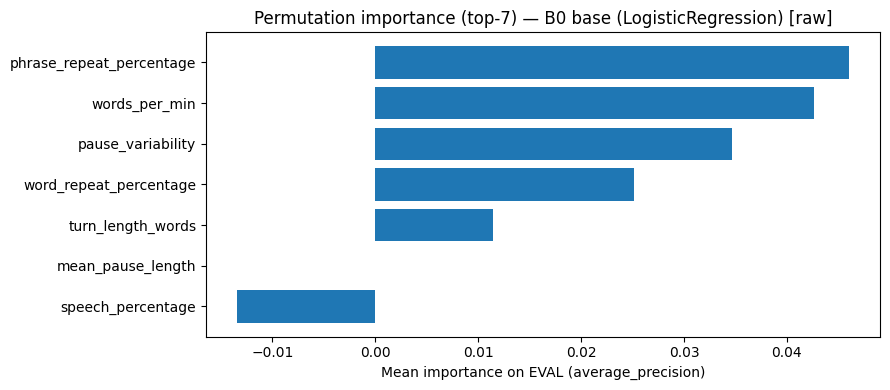


=== L base: LogisticRegression [default] ===

Classification report:
               precision    recall  f1-score   support

           0      0.812     0.667     0.732        39
           1      0.458     0.647     0.537        17

    accuracy                          0.661        56
   macro avg      0.635     0.657     0.634        56
weighted avg      0.705     0.661     0.673        56

Confusion matrix:
 [[26 13]
 [ 6 11]]

[L base (LogisticRegression)] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
              semantic_perplexity_mean         0.257700        0.041544
                word_coherence_10_mean         0.190849        0.070661
first_order_sentence_tangeniality_mean         0.127478        0.062119
                     sentiment_overall         0.075897        0.019957
                         sentiment_pos         0.030184        0.027588
               first_person_percentage      

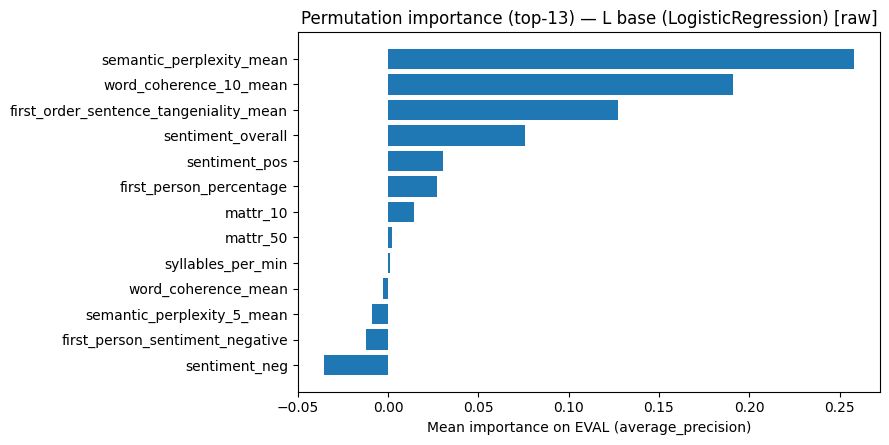


=== FUSED (meta LogisticRegression on [p_B0, p_L]) ===
Meta weights: {'intercept': -0.8364885469661512, 'w_pB0': 1.4634428743729273, 'w_pL': 0.2720507904794861}

Classification report:
               precision    recall  f1-score   support

           0      0.793     0.590     0.676        39
           1      0.407     0.647     0.500        17

    accuracy                          0.607        56
   macro avg      0.600     0.618     0.588        56
weighted avg      0.676     0.607     0.623        56

Confusion matrix:
 [[23 16]
 [ 6 11]]


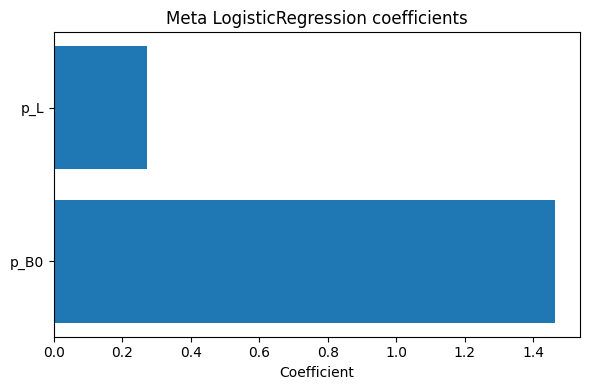


=== Summary metrics on TEST (tuned by PR AUC) ===
  stage                  model  tuned  cv_best_score best_params  n_train  n_test  n_features_raw  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  pr_auc_lo  pr_auc_hi  brier
B0 base     LogisticRegression  False            NaN                  219      56               7    0.6607    0.6345 0.5083 0.7610        0.6569   0.6018  0.4193  0.7708  0.4371     0.3149     0.6718 0.2498
 L base     LogisticRegression  False            NaN                  219      56              13    0.6607    0.6345 0.5048 0.7499        0.6569   0.6878  0.5204  0.8356  0.5651     0.4017     0.7675 0.2170
  FUSED MetaLogisticRegression  False            NaN  meta_C=1.0      219      56               2    0.6071    0.5882 0.4613 0.7135        0.6184   0.6290  0.4449  0.7949  0.4804     0.3397     0.7153 0.2387


In [10]:
res = run_late_fusion_pipeline_clean(
    dataset_b0_path=f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    dataset_l_path=f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_{LANGUAGE}_small_test{ITERATION}.csv",
    base_model_b0="LogisticRegression",
    base_model_l="LogisticRegression",
    tune_tree_models=False,
    compute_importance=True,
    # feature_selection=False,  # set True to do train-only raw-column selection per modality
    target_col='Depression_label',
)

In [11]:
res

,stage,model,tuned,cv_best_score,best_params,n_train,n_test,n_features_raw,accuracy,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,pr_auc_lo,pr_auc_hi,brier
0,B0 base,LogisticRegression,False,NaN,,219,56,7,0.660714,0.634490,0.508254,0.761024,0.656863,0.601810,0.419268,0.770814,0.437071,0.314877,0.671812,0.249801
1,L base,LogisticRegression,False,NaN,,219,56,13,0.660714,0.634490,0.504762,0.749914,0.656863,0.687783,0.520362,0.835633,0.565066,0.401735,0.767479,0.216968
2,FUSED,MetaLogisticRegression,False,NaN,meta_C=1.0,219,56,2,0.607143,0.588235,0.461277,0.713536,0.618401,0.628959,0.444947,0.794910,0.480419,0.339668,0.715334,0.238670
